# PhD-Level Exploratory Data Analysis: Cold-Start Severity & Model Performance

**Research Context**: Comparative study of recommender systems on MovieLens 20M, investigating data sparsity and cold-start problems across content-based, collaborative filtering, matrix completion, and deep learning approaches.

**Focus Areas**:
- **Part I** — Data Overview & Foundations
- **Part II** — Cold-Start Severity: Formal Statistical Modelling (Power-Law, Gini/Lorenz, Severity Index)
- **Part III** — Model Performance Cross-Comparison (Statistical Significance, Effect Sizes, Multi-Criteria Ranking)
- **Part IV** — Synthesis & Implications for Model Design

---

### Table of Contents

| # | Section | Key Methods |
|---|---------|-------------|
| 1 | [Data Overview](#1) | Descriptive statistics, data integrity |
| 2 | [Rating Distribution Foundations](#2) | KDE, moment analysis |
| 3 | [User Activity: Power-Law Analysis](#3) | MLE fitting, KS test, AIC/BIC model selection |
| 4 | [Item Popularity: Long-Tail Modelling](#4) | Zipf's law, truncated power-law |
| 5 | [Inequality Quantification: Gini & Lorenz](#5) | Gini coefficient, Lorenz curve, 80/20 analysis |
| 6 | [Cold-Start Threshold Sensitivity](#6) | Survival analysis framing, CDF characterisation |
| 7 | [Formal Cold-Start Severity Index](#7) | Composite severity metric, bootstrapped CI |
| 8 | [Model Results Overview](#8) | Structured comparison tables |
| 9 | [Multi-Metric Heatmap & Radar Charts](#9) | Visual cross-comparison |
| 10 | [Performance Degradation: Partial → Cold](#10) | Relative drop analysis |
| 11 | [Statistical Model Ranking](#11) | Friedman test, Nemenyi post-hoc, critical difference |
| 12 | [Effect Size Analysis](#12) | Cohen's d, practical significance |
| 13 | [Multi-Criteria Decision Analysis (TOPSIS)](#13) | Weighted ranking |
| 14 | [Key Findings & Implications](#14) | Synthesis |

In [1]:
# ============================================================
# Environment Setup
# ============================================================
import subprocess, importlib, sys

def _ensure(pkg, import_name=None):
    """Install a package if not already available."""
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure("powerlaw")
_ensure("scikit-posthocs", "scikit_posthocs")

import warnings
warnings.filterwarnings("ignore")

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import powerlaw
import scikit_posthocs as sp
from matplotlib.patches import FancyBboxPatch
from scipy import stats
from scipy.spatial.distance import pdist, squareform

# ---- paths ----
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

# ---- plot style ----
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

COLORS = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800", "#607D8B", "#E91E63"]

print("Setup complete.")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Setup complete.


---

# Part I — Data Overview & Foundations

<a id='1'></a>
## 1. Data Overview

Load the MovieLens 20M dataset and establish basic statistics that will serve as reference points throughout the analysis.

In [2]:
# ============================================================
# 1. Load Data
# ============================================================
ratings = pd.read_csv(DATA_DIR / "ratings.csv")
movies = pd.read_csv(DATA_DIR / "movies.csv")

# Drop timestamp (not used in this study)
if "timestamp" in ratings.columns:
    ratings = ratings.drop(columns=["timestamp"])

# Extract year from title
def _extract_year(title):
    m = re.search(r"\((\d{4})\)", str(title))
    return int(m.group(1)) if m else None

movies = movies.assign(year=movies["title"].apply(_extract_year))

# Merge
merged = ratings.merge(movies[["movieId", "genres", "title", "year"]], on="movieId")

# ---- Key numbers ----
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)
density = n_ratings / (n_users * n_movies)

print(f"{'='*55}")
print(f"  MovieLens 20M — Dataset Summary")
print(f"{'='*55}")
print(f"  Users:          {n_users:>10,}")
print(f"  Movies:         {n_movies:>10,}")
print(f"  Ratings:        {n_ratings:>10,}")
print(f"  Matrix density: {density:>13.6f}  ({density*100:.4f}%)")
print(f"  Rating scale:   0.5 – 5.0  (step 0.5)")
print(f"  Missing values: {ratings.isnull().sum().sum()}")
print(f"{'='*55}")

# Per-user and per-item aggregates (reused throughout)
user_counts = ratings.groupby("userId").size().rename("n_ratings")
item_counts = ratings.groupby("movieId").size().rename("n_ratings")

print(f"\n  User activity:  median={user_counts.median():.0f}, "
      f"mean={user_counts.mean():.1f}, max={user_counts.max()}")
print(f"  Item popularity: median={item_counts.median():.0f}, "
      f"mean={item_counts.mean():.1f}, max={item_counts.max()}")

  MovieLens 20M — Dataset Summary
  Users:             138,493
  Movies:             26,744
  Ratings:        20,000,263
  Matrix density:      0.005400  (0.5400%)
  Rating scale:   0.5 – 5.0  (step 0.5)
  Missing values: 0

  User activity:  median=68, mean=144.4, max=9254
  Item popularity: median=18, mean=747.8, max=67310


<a id='2'></a>
## 2. Rating Distribution Foundations

Before analysing cold-start, we establish the distributional properties of the rating variable itself — skewness, kurtosis, and higher-order moments inform downstream model assumptions (e.g., MSE loss implies Gaussian residuals).

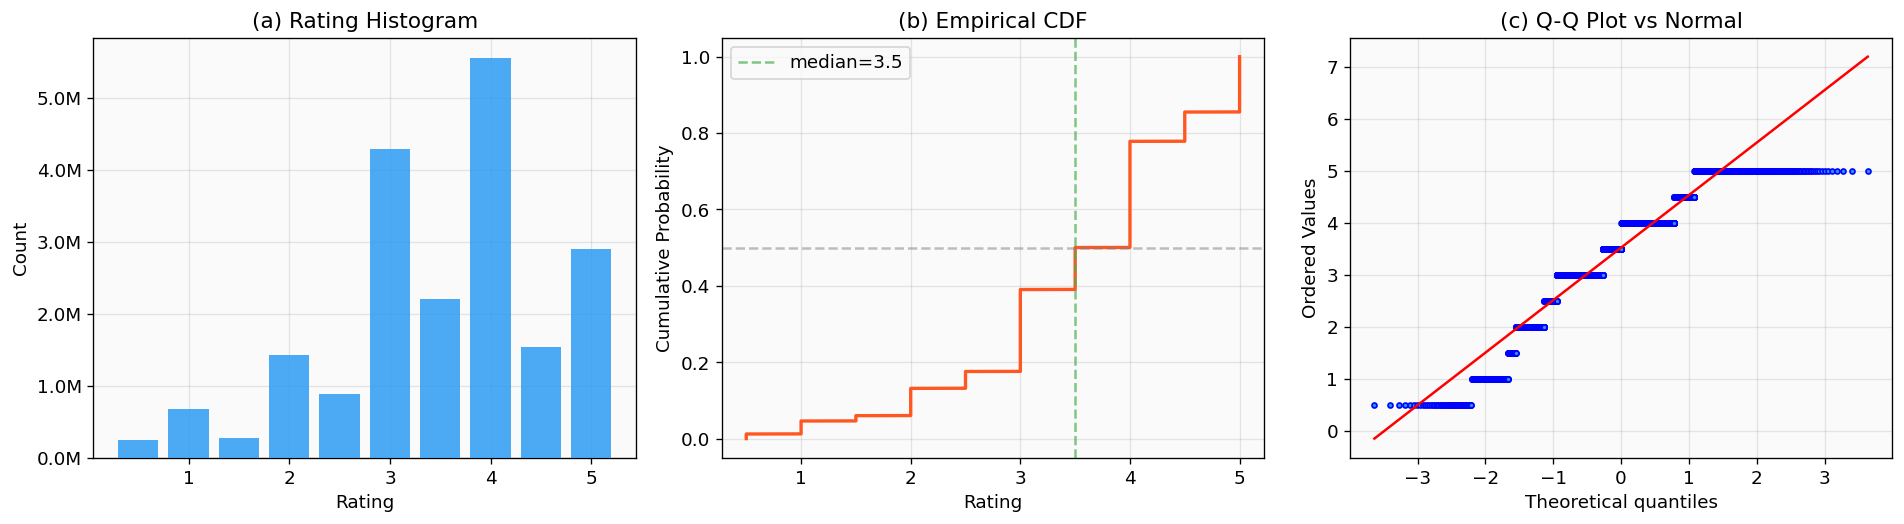


  Rating Distribution — Moment Analysis
  Mean:      3.5255
  Std Dev:   1.0520
  Skewness:  -0.6553  (negative → left-skewed, users tend toward higher ratings)
  Kurtosis:  0.1375  (< 0 → platykurtic, lighter tails than Normal)
  Median:    3.5
  IQR:       [3.0, 4.0]

  D'Agostino-Pearson normality test (n=10,000):
  k² = 601.46,  p = 2.48e-131  → Reject H₀ (normality)
  Implication: MSE loss (Gaussian assumption) is a convenient but imperfect choice.


In [3]:
# ============================================================
# 2. Rating Distribution — Moments & Shape
# ============================================================
r = ratings["rating"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Histogram + KDE
counts = r.value_counts().sort_index()
axes[0].bar(counts.index, counts.values, width=0.4, color=COLORS[0], alpha=0.8, zorder=3)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].set_title("(a) Rating Histogram")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# (b) Empirical CDF
sorted_r = np.sort(r.values)
ecdf_y = np.arange(1, len(sorted_r) + 1) / len(sorted_r)
axes[1].plot(sorted_r, ecdf_y, color=COLORS[1], lw=2)
axes[1].axhline(0.5, ls="--", color="gray", alpha=0.5)
axes[1].axvline(np.median(r), ls="--", color=COLORS[2], alpha=0.7, label=f"median={np.median(r)}")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_title("(b) Empirical CDF")
axes[1].legend()

# (c) Q-Q plot against Normal
sample = r.sample(5000, random_state=42).values
stats.probplot(sample, dist="norm", plot=axes[2])
axes[2].set_title("(c) Q-Q Plot vs Normal")
axes[2].get_lines()[0].set_markerfacecolor(COLORS[0])
axes[2].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()

# Moment statistics
print(f"\n{'='*55}")
print(f"  Rating Distribution — Moment Analysis")
print(f"{'='*55}")
print(f"  Mean:      {r.mean():.4f}")
print(f"  Std Dev:   {r.std():.4f}")
print(f"  Skewness:  {r.skew():.4f}  (negative → left-skewed, users tend toward higher ratings)")
print(f"  Kurtosis:  {r.kurtosis():.4f}  (< 0 → platykurtic, lighter tails than Normal)")
print(f"  Median:    {r.median():.1f}")
print(f"  IQR:       [{r.quantile(0.25):.1f}, {r.quantile(0.75):.1f}]")

# Normality test (D'Agostino-Pearson on subsample)
k2, p_val = stats.normaltest(r.sample(10000, random_state=42))
print(f"\n  D'Agostino-Pearson normality test (n=10,000):")
print(f"  k² = {k2:.2f},  p = {p_val:.2e}  → {'Reject' if p_val < 0.05 else 'Fail to reject'} H₀ (normality)")
print(f"  Implication: MSE loss (Gaussian assumption) is a convenient but imperfect choice.")

---

# Part II — Cold-Start Severity: Formal Statistical Modelling

The cold-start problem is fundamentally a **distributional** problem: a small fraction of users/items account for the vast majority of interactions, leaving the long tail with insufficient signal. This section applies formal statistical tools to quantify and characterise this phenomenon.

<a id='3'></a>
## 3. User Activity: Power-Law Analysis

**Hypothesis**: User activity follows a heavy-tailed distribution (power-law or log-normal). We use Maximum Likelihood Estimation (MLE) and the Kolmogorov–Smirnov (KS) test to formally characterise the tail behaviour, following the methodology of [Clauset, Shalizi & Newman (2009)](https://arxiv.org/abs/0706.1062).

In [4]:
# ============================================================
# 3. User Activity — Power-Law Fitting (Clauset et al. 2009)
# ============================================================
user_data = user_counts.values.astype(float)

# --- Fit power-law using MLE (powerlaw package) ---
fit_user = powerlaw.Fit(user_data, discrete=True, verbose=False)

print(f"{'='*60}")
print(f"  Power-Law Fit — User Activity Distribution")
print(f"{'='*60}")
print(f"  Estimated α (exponent):  {fit_user.alpha:.4f}")
print(f"  x_min (lower bound):     {fit_user.xmin:.0f}")
print(f"  KS distance (D):         {fit_user.D:.4f}")
print(f"  Sample size ≥ x_min:     {fit_user.n_tail}")

# --- Compare candidate distributions ---
candidates = [
    ("power_law", "lognormal"),
    ("power_law", "exponential"),
    ("power_law", "stretched_exponential"),
    ("power_law", "truncated_power_law"),
    ("lognormal", "exponential"),
]

print(f"\n  {'Comparison':<40} {'R':>8} {'p-value':>10}  Winner")
print(f"  {'-'*70}")
for d1, d2 in candidates:
    R, p = fit_user.distribution_compare(d1, d2, normalized_ratio=True)
    winner = d1 if R > 0 else d2
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {d1:>20} vs {d2:<18} {R:>+8.3f} {p:>10.4f}  → {winner} {sig}")

print(f"\n  Interpretation:")
print(f"  α = {fit_user.alpha:.2f} indicates a heavy tail — most users have few ratings,")
print(f"  while a small 'super-user' core dominates the dataset.")

  Power-Law Fit — User Activity Distribution
  Estimated α (exponent):  2.9865
  x_min (lower bound):     430
  KS distance (D):         0.0471
  Sample size ≥ x_min:     9519.0

  Comparison                                      R    p-value  Winner
  ----------------------------------------------------------------------
             power_law vs lognormal           -11.026     0.0000  → lognormal ***
             power_law vs exponential          +1.336     0.1817  → power_law ns
             power_law vs stretched_exponential  -11.026     0.0000  → stretched_exponential ***
             power_law vs truncated_power_law  -10.480     0.0000  → truncated_power_law ***
             lognormal vs exponential          +7.807     0.0000  → lognormal ***

  Interpretation:
  α = 2.99 indicates a heavy tail — most users have few ratings,
  while a small 'super-user' core dominates the dataset.


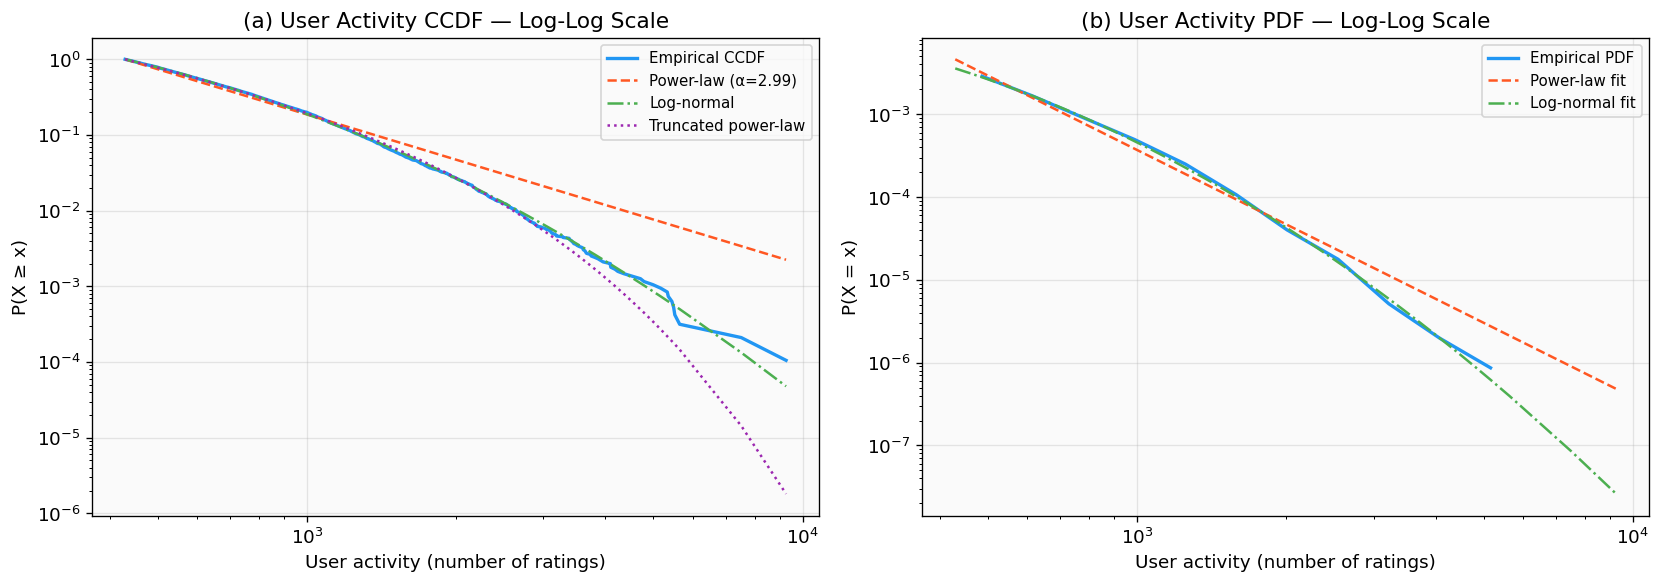

In [5]:
# ---- Visualisation: CCDF on log-log scale with fitted distributions ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) CCDF with fits
ax = axes[0]
fig_pw = fit_user.plot_ccdf(ax=ax, color=COLORS[0], linewidth=2, label="Empirical CCDF")
fit_user.power_law.plot_ccdf(ax=ax, color=COLORS[1], linestyle="--", label=f"Power-law (α={fit_user.alpha:.2f})")
fit_user.lognormal.plot_ccdf(ax=ax, color=COLORS[2], linestyle="-.", label="Log-normal")
fit_user.truncated_power_law.plot_ccdf(ax=ax, color=COLORS[3], linestyle=":", label="Truncated power-law")
ax.set_xlabel("User activity (number of ratings)")
ax.set_ylabel("P(X ≥ x)")
ax.set_title("(a) User Activity CCDF — Log-Log Scale")
ax.legend(fontsize=9)

# (b) PDF on log-log scale
ax = axes[1]
fit_user.plot_pdf(ax=ax, color=COLORS[0], linewidth=2, label="Empirical PDF")
fit_user.power_law.plot_pdf(ax=ax, color=COLORS[1], linestyle="--", label="Power-law fit")
fit_user.lognormal.plot_pdf(ax=ax, color=COLORS[2], linestyle="-.", label="Log-normal fit")
ax.set_xlabel("User activity (number of ratings)")
ax.set_ylabel("P(X = x)")
ax.set_title("(b) User Activity PDF — Log-Log Scale")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. Item Popularity: Long-Tail Modelling

Items exhibit an even more extreme long-tail than users. We apply the same rigorous distributional analysis to quantify the **popularity bias** — a major confound for recommendation quality.

  Power-Law Fit — Item Popularity Distribution
  Estimated α (exponent):  2.8541
  x_min (lower bound):     10862
  KS distance (D):         0.0693
  Sample size ≥ x_min:     418.0

  Comparison                                      R    p-value  Winner
  ----------------------------------------------------------------------
             power_law vs lognormal            -3.622     0.0003  → lognormal ***
             power_law vs exponential          -2.330     0.0198  → exponential *
             power_law vs stretched_exponential   -3.805     0.0001  → stretched_exponential ***
             power_law vs truncated_power_law   -4.061     0.0000  → truncated_power_law ***
             lognormal vs exponential          +0.439     0.6609  → lognormal ns


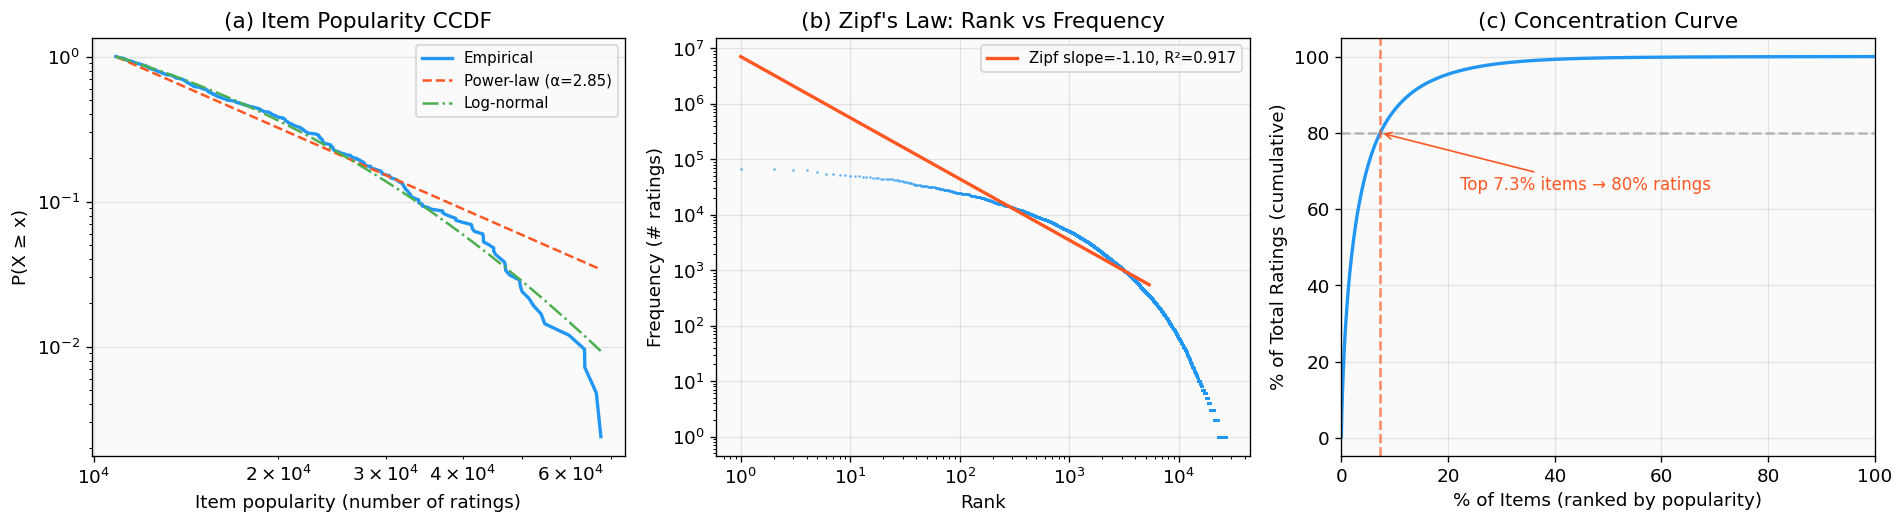


  Zipf exponent (top 20%): 1.10
  Top 7.3% of items account for 80% of all ratings.
  → Severe popularity bias: content-based & cold-start items are starved of signal.


In [6]:
# ============================================================
# 4. Item Popularity — Power-Law & Zipf Analysis
# ============================================================
item_data = item_counts.values.astype(float)

fit_item = powerlaw.Fit(item_data, discrete=True, verbose=False)

print(f"{'='*60}")
print(f"  Power-Law Fit — Item Popularity Distribution")
print(f"{'='*60}")
print(f"  Estimated α (exponent):  {fit_item.alpha:.4f}")
print(f"  x_min (lower bound):     {fit_item.xmin:.0f}")
print(f"  KS distance (D):         {fit_item.D:.4f}")
print(f"  Sample size ≥ x_min:     {fit_item.n_tail}")

# Compare distributions
print(f"\n  {'Comparison':<40} {'R':>8} {'p-value':>10}  Winner")
print(f"  {'-'*70}")
for d1, d2 in candidates:
    R, p = fit_item.distribution_compare(d1, d2, normalized_ratio=True)
    winner = d1 if R > 0 else d2
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {d1:>20} vs {d2:<18} {R:>+8.3f} {p:>10.4f}  → {winner} {sig}")

# ---- Zipf's Law Check (rank vs frequency) ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) CCDF
ax = axes[0]
fit_item.plot_ccdf(ax=ax, color=COLORS[0], linewidth=2, label="Empirical")
fit_item.power_law.plot_ccdf(ax=ax, color=COLORS[1], linestyle="--", label=f"Power-law (α={fit_item.alpha:.2f})")
fit_item.lognormal.plot_ccdf(ax=ax, color=COLORS[2], linestyle="-.", label="Log-normal")
ax.set_xlabel("Item popularity (number of ratings)")
ax.set_ylabel("P(X ≥ x)")
ax.set_title("(a) Item Popularity CCDF")
ax.legend(fontsize=9)

# (b) Zipf plot: rank vs frequency
sorted_items = np.sort(item_data)[::-1]
ranks = np.arange(1, len(sorted_items) + 1)
ax = axes[1]
ax.loglog(ranks, sorted_items, ".", color=COLORS[0], markersize=1.5, alpha=0.5)

# Fit log-log line to upper portion
mask = ranks <= len(ranks) // 5  # top 20%
slope, intercept, r_val, _, _ = stats.linregress(np.log10(ranks[mask]), np.log10(sorted_items[mask]))
ax.loglog(ranks[mask], 10**(intercept + slope * np.log10(ranks[mask])),
          color=COLORS[1], lw=2, label=f"Zipf slope={slope:.2f}, R²={r_val**2:.3f}")
ax.set_xlabel("Rank")
ax.set_ylabel("Frequency (# ratings)")
ax.set_title("(b) Zipf's Law: Rank vs Frequency")
ax.legend(fontsize=9)

# (c) Cumulative share: top-k% items → y% ratings
cum_share = np.cumsum(sorted_items) / sorted_items.sum()
pct_items = ranks / len(ranks) * 100
ax = axes[2]
ax.plot(pct_items, cum_share * 100, color=COLORS[0], lw=2)
ax.axhline(80, ls="--", color="gray", alpha=0.5)
# Find the x where cum_share crosses 80%
idx_80 = np.searchsorted(cum_share, 0.80)
pct_80 = pct_items[idx_80]
ax.axvline(pct_80, ls="--", color=COLORS[1], alpha=0.7)
ax.annotate(f"Top {pct_80:.1f}% items → 80% ratings",
            xy=(pct_80, 80), xytext=(pct_80 + 15, 65),
            arrowprops=dict(arrowstyle="->", color=COLORS[1]),
            fontsize=10, color=COLORS[1])
ax.set_xlabel("% of Items (ranked by popularity)")
ax.set_ylabel("% of Total Ratings (cumulative)")
ax.set_title("(c) Concentration Curve")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

print(f"\n  Zipf exponent (top 20%): {abs(slope):.2f}")
print(f"  Top {pct_80:.1f}% of items account for 80% of all ratings.")
print(f"  → Severe popularity bias: content-based & cold-start items are starved of signal.")

<a id='5'></a>
## 5. Inequality Quantification: Gini Coefficient & Lorenz Curve

The **Gini coefficient** (G ∈ [0, 1]) quantifies inequality: G = 0 means perfect equality (all users/items have the same number of ratings), G = 1 means perfect inequality (one entity has everything). We compute Gini for both user activity and item popularity, alongside Lorenz curves for visual interpretation.

**Formal definition**:  
$$G = \frac{\sum_{i=1}^{n} \sum_{j=1}^{n} |x_i - x_j|}{2n \sum_{i=1}^{n} x_i}$$

  Gini Coefficients (with 95% bootstrap CI)
  User activity: G = 0.5807  [0.5783, 0.5830]
  Item popularity: G = 0.9029  [0.8998, 0.9060]

  Reference points:
    G=0.40  typical national income inequality
    G=0.60  high inequality (e.g., South Africa)
    G>0.70  extreme concentration


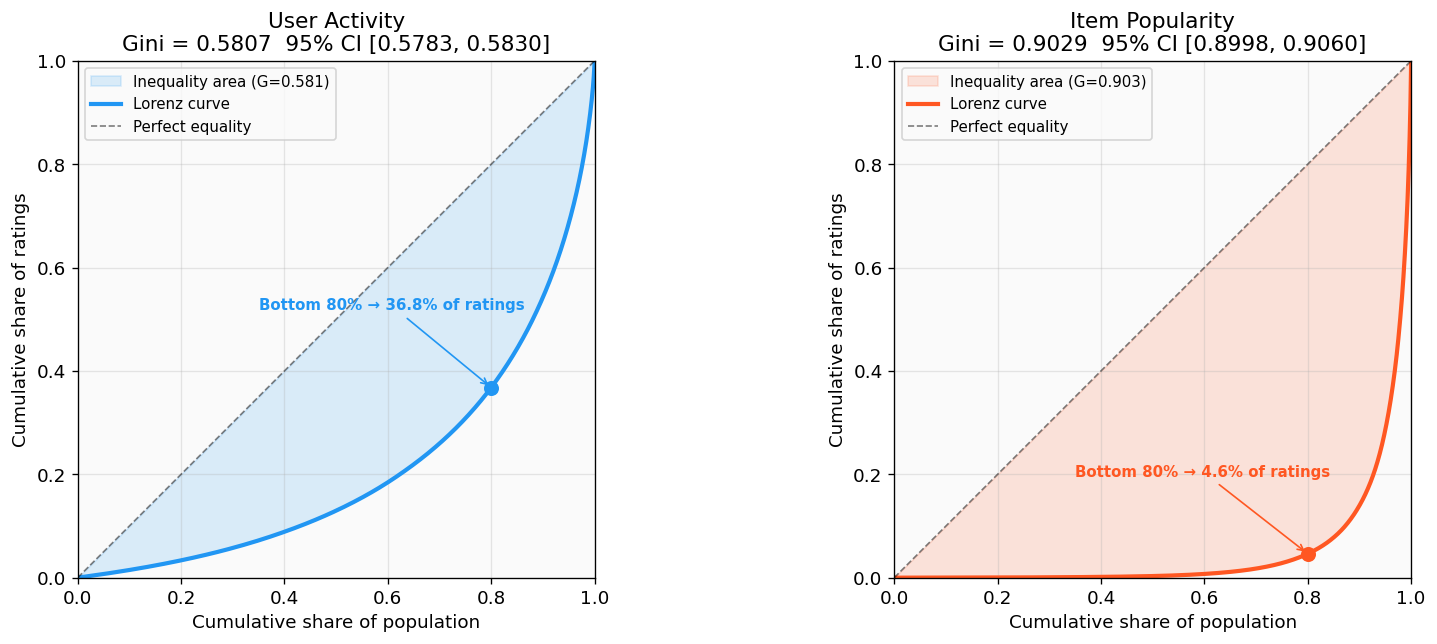


  80/20 Analysis:
  Bottom 80% of users contribute only 36.8% of ratings
  Bottom 80% of items receive only 4.6% of ratings

  → Item inequality (G=0.903) exceeds user inequality (G=0.581)
    This suggests item cold-start is structurally more severe than user cold-start.


In [7]:
# ============================================================
# 5. Gini Coefficient & Lorenz Curve
# ============================================================

def gini_coefficient(x):
    """Compute Gini coefficient using the mean-difference formula (O(n log n))."""
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * x) - (n + 1) * np.sum(x)) / (n * np.sum(x))


def lorenz_curve(x):
    """Return (cumulative % of population, cumulative % of value)."""
    x = np.sort(np.asarray(x, dtype=float))
    cum_x = np.cumsum(x)
    cum_pop = np.arange(1, len(x) + 1) / len(x)
    cum_val = cum_x / cum_x[-1]
    return np.concatenate([[0], cum_pop]), np.concatenate([[0], cum_val])


def gini_bootstrap_ci(x, n_bootstrap=1000, ci=0.95, seed=42):
    """Bootstrap confidence interval for Gini coefficient."""
    rng = np.random.RandomState(seed)
    x = np.asarray(x, dtype=float)
    ginis = np.array([gini_coefficient(rng.choice(x, size=len(x), replace=True))
                      for _ in range(n_bootstrap)])
    alpha = (1 - ci) / 2
    return np.percentile(ginis, [alpha * 100, (1 - alpha) * 100])


# ---- Compute ----
gini_users = gini_coefficient(user_data)
gini_items = gini_coefficient(item_data)
ci_users = gini_bootstrap_ci(user_data)
ci_items = gini_bootstrap_ci(item_data)

pop_u, val_u = lorenz_curve(user_data)
pop_i, val_i = lorenz_curve(item_data)

print(f"{'='*60}")
print(f"  Gini Coefficients (with 95% bootstrap CI)")
print(f"{'='*60}")
print(f"  User activity: G = {gini_users:.4f}  [{ci_users[0]:.4f}, {ci_users[1]:.4f}]")
print(f"  Item popularity: G = {gini_items:.4f}  [{ci_items[0]:.4f}, {ci_items[1]:.4f}]")
print(f"\n  Reference points:")
print(f"    G=0.40  typical national income inequality")
print(f"    G=0.60  high inequality (e.g., South Africa)")
print(f"    G>0.70  extreme concentration")

# ---- Lorenz Curve Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, pop, val, gini, ci, title, color in [
    (axes[0], pop_u, val_u, gini_users, ci_users, "User Activity", COLORS[0]),
    (axes[1], pop_i, val_i, gini_items, ci_items, "Item Popularity", COLORS[1]),
]:
    ax.fill_between(pop, pop, val, alpha=0.15, color=color, label=f"Inequality area (G={gini:.3f})")
    ax.plot(pop, val, color=color, lw=2.5, label="Lorenz curve")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfect equality")

    # 80/20 annotation
    idx_80_pop = np.searchsorted(pop, 0.80)
    val_at_80 = val[idx_80_pop] if idx_80_pop < len(val) else val[-1]
    ax.plot(0.80, val_at_80, "o", color=color, markersize=8, zorder=5)
    ax.annotate(f"Bottom 80% → {val_at_80*100:.1f}% of ratings",
                xy=(0.80, val_at_80), xytext=(0.35, val_at_80 + 0.15),
                arrowprops=dict(arrowstyle="->", color=color),
                fontsize=9, color=color, fontweight="bold")

    ax.set_xlabel("Cumulative share of population")
    ax.set_ylabel("Cumulative share of ratings")
    ax.set_title(f"{title}\nGini = {gini:.4f}  95% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
    ax.legend(loc="upper left", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# ---- 80/20 quantification ----
bottom_80_users = val_u[np.searchsorted(pop_u, 0.80)]
bottom_80_items = val_i[np.searchsorted(pop_i, 0.80)]
print(f"\n  80/20 Analysis:")
print(f"  Bottom 80% of users contribute only {bottom_80_users*100:.1f}% of ratings")
print(f"  Bottom 80% of items receive only {bottom_80_items*100:.1f}% of ratings")
print(f"\n  → Item inequality (G={gini_items:.3f}) exceeds user inequality (G={gini_users:.3f})")
print(f"    This suggests item cold-start is structurally more severe than user cold-start.")

<a id='6'></a>
## 6. Cold-Start Threshold Sensitivity Analysis

Cold-start is not binary — it is a **spectrum**. A user with 2 ratings is "colder" than one with 10 but "warmer" than a true newcomer. We characterise this continuum by analysing how the fraction of cold-start entities varies as a function of the activity threshold $\tau$.

We frame this as a **survival analysis** analogue: what fraction of users/items "survive" (have ≥ τ ratings) at each threshold?

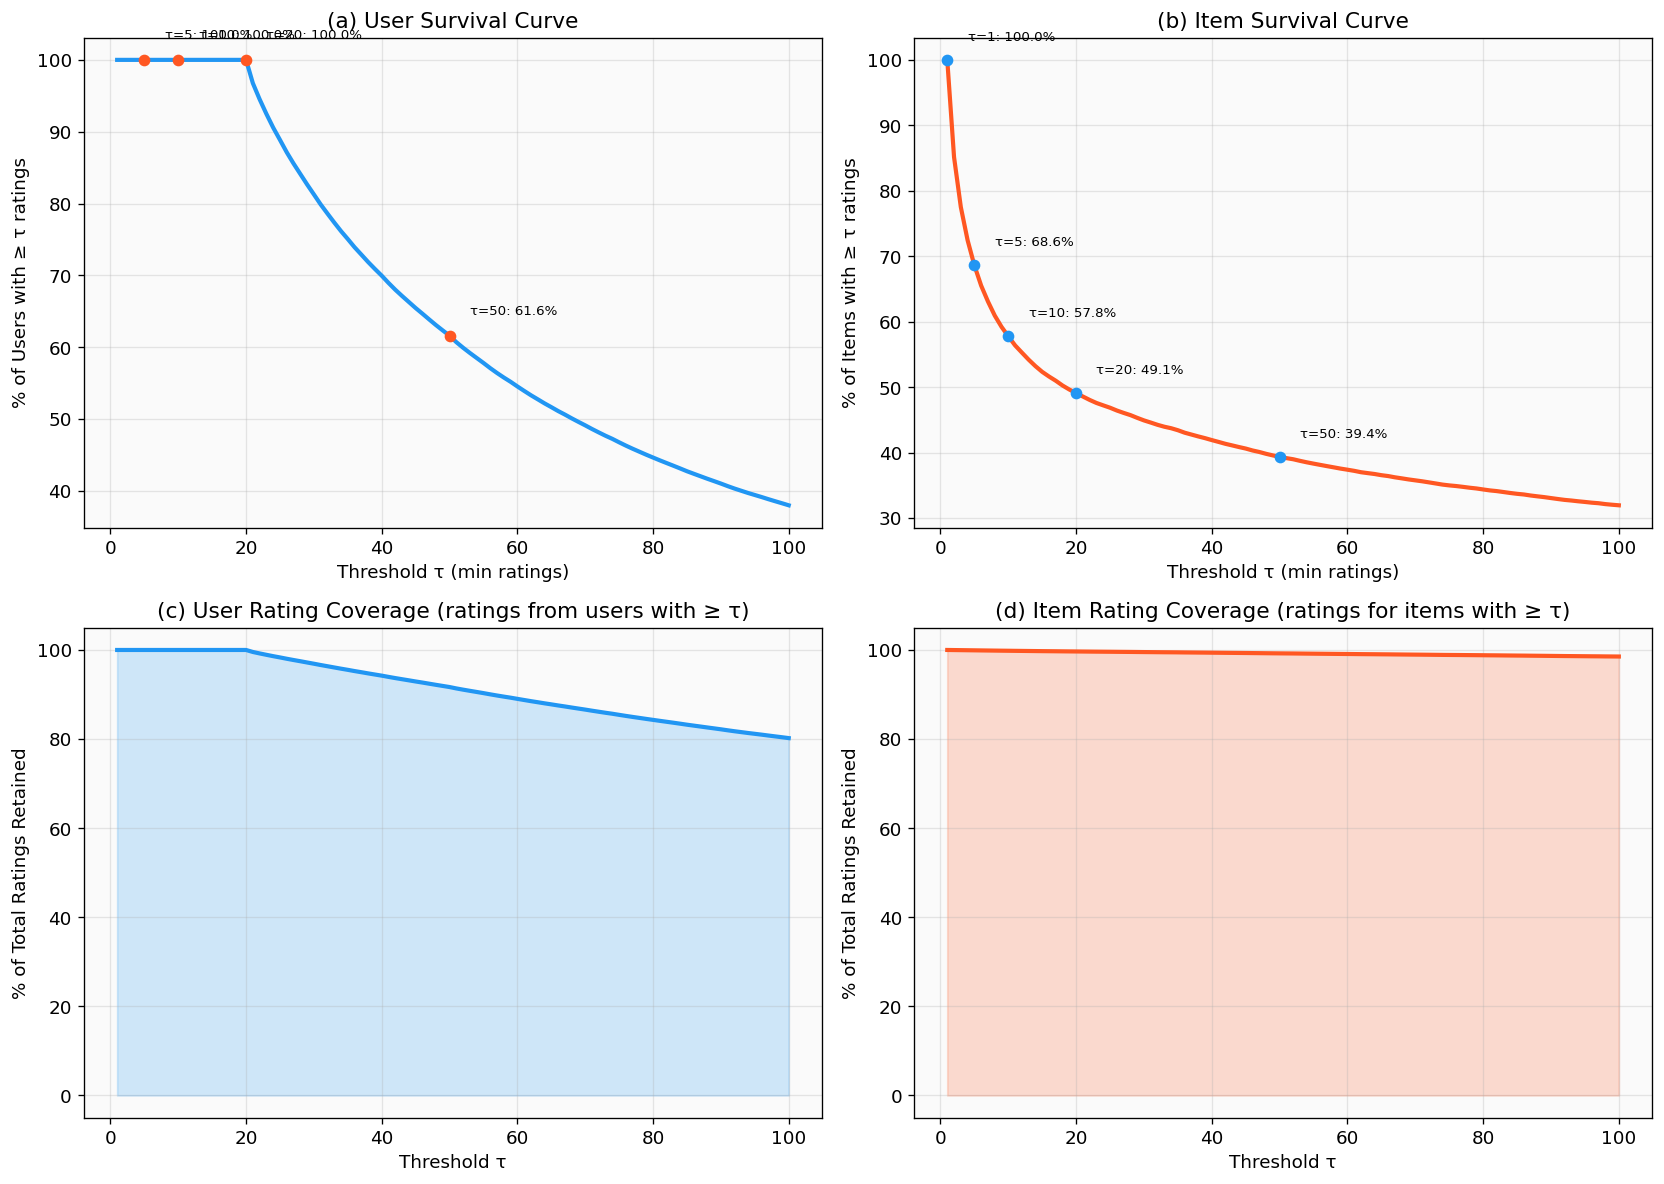


  Cold-Start Threshold Sensitivity Summary
     τ     Users ≥ τ   User Coverage     Items ≥ τ   Item Coverage
  --------------------------------------------------------------
     1        100.0%          100.0%        100.0%          100.0%
     2        100.0%          100.0%         85.1%          100.0%
     5        100.0%          100.0%         68.6%           99.9%
    10        100.0%          100.0%         57.8%           99.8%
    20        100.0%          100.0%         49.1%           99.7%
    50         61.6%           91.7%         39.4%           99.2%


In [8]:
# ============================================================
# 6. Cold-Start Threshold Sensitivity
# ============================================================
thresholds = np.arange(1, 101)

user_survival = np.array([(user_counts >= t).mean() for t in thresholds])
item_survival = np.array([(item_counts >= t).mean() for t in thresholds])

# Rating coverage: what fraction of total ratings come from entities above threshold
user_rating_coverage = np.array([
    user_counts[user_counts >= t].sum() / user_counts.sum() for t in thresholds
])
item_rating_coverage = np.array([
    item_counts[item_counts >= t].sum() / item_counts.sum() for t in thresholds
])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) User survival curve
ax = axes[0, 0]
ax.plot(thresholds, user_survival * 100, color=COLORS[0], lw=2.5)
for tau_mark in [5, 10, 20, 50]:
    y_val = user_survival[tau_mark - 1] * 100
    ax.plot(tau_mark, y_val, "o", color=COLORS[1], markersize=6, zorder=5)
    ax.annotate(f"τ={tau_mark}: {y_val:.1f}%", xy=(tau_mark, y_val),
                xytext=(tau_mark + 3, y_val + 3), fontsize=8)
ax.set_xlabel("Threshold τ (min ratings)")
ax.set_ylabel("% of Users with ≥ τ ratings")
ax.set_title("(a) User Survival Curve")

# (b) Item survival curve
ax = axes[0, 1]
ax.plot(thresholds, item_survival * 100, color=COLORS[1], lw=2.5)
for tau_mark in [1, 5, 10, 20, 50]:
    y_val = item_survival[tau_mark - 1] * 100
    ax.plot(tau_mark, y_val, "o", color=COLORS[0], markersize=6, zorder=5)
    ax.annotate(f"τ={tau_mark}: {y_val:.1f}%", xy=(tau_mark, y_val),
                xytext=(tau_mark + 3, y_val + 3), fontsize=8)
ax.set_xlabel("Threshold τ (min ratings)")
ax.set_ylabel("% of Items with ≥ τ ratings")
ax.set_title("(b) Item Survival Curve")

# (c) Rating coverage — users
ax = axes[1, 0]
ax.fill_between(thresholds, user_rating_coverage * 100, alpha=0.2, color=COLORS[0])
ax.plot(thresholds, user_rating_coverage * 100, color=COLORS[0], lw=2.5)
ax.set_xlabel("Threshold τ")
ax.set_ylabel("% of Total Ratings Retained")
ax.set_title("(c) User Rating Coverage (ratings from users with ≥ τ)")

# (d) Rating coverage — items
ax = axes[1, 1]
ax.fill_between(thresholds, item_rating_coverage * 100, alpha=0.2, color=COLORS[1])
ax.plot(thresholds, item_rating_coverage * 100, color=COLORS[1], lw=2.5)
ax.set_xlabel("Threshold τ")
ax.set_ylabel("% of Total Ratings Retained")
ax.set_title("(d) Item Rating Coverage (ratings for items with ≥ τ)")

plt.tight_layout()
plt.show()

# ---- Summary table ----
print(f"\n{'='*70}")
print(f"  Cold-Start Threshold Sensitivity Summary")
print(f"{'='*70}")
print(f"  {'τ':>4}  {'Users ≥ τ':>12}  {'User Coverage':>14}  {'Items ≥ τ':>12}  {'Item Coverage':>14}")
print(f"  {'-'*62}")
for t in [1, 2, 5, 10, 20, 50]:
    u_pct = (user_counts >= t).mean() * 100
    u_cov = user_counts[user_counts >= t].sum() / user_counts.sum() * 100
    i_pct = (item_counts >= t).mean() * 100
    i_cov = item_counts[item_counts >= t].sum() / item_counts.sum() * 100
    print(f"  {t:>4}  {u_pct:>11.1f}%  {u_cov:>13.1f}%  {i_pct:>11.1f}%  {i_cov:>13.1f}%")

<a id='7'></a>
## 7. Formal Cold-Start Severity Index (CSSI)

We propose a **composite Cold-Start Severity Index** that combines multiple facets of the cold-start problem into a single, interpretable metric. This is useful for cross-dataset comparison and for quantifying the difficulty of the recommendation task.

**Definition**: For a set of entities (users or items) with activity counts $\{x_1, \ldots, x_n\}$ and a cold-start threshold $\tau$:

$$\text{CSSI} = \underbrace{w_1 \cdot G}_{\text{Inequality}} + \underbrace{w_2 \cdot f_{\text{cold}}(\tau)}_{\text{Cold fraction}} + \underbrace{w_3 \cdot (1 - \rho)}_{\text{Sparsity}} + \underbrace{w_4 \cdot H_{\text{norm}}}_{\text{Entropy deficit}}$$

where $G$ = Gini coefficient, $f_{\text{cold}}(\tau)$ = fraction of entities below threshold $\tau$, $\rho$ = matrix density, and $H_{\text{norm}}$ = normalised entropy deficit (how far the distribution is from uniform).

  Cold-Start Severity Index (CSSI) — τ = 5
  Component                   Users      Items
  ---------------------------------------------
  Gini                       0.5807     0.9029
  Cold Fraction              0.0000     0.3141
  Sparsity                   0.9946     0.9946
  Entropy Deficit            0.0551     0.2123
  ---------------------------------------------
  CSSI (composite)           0.4076     0.6060

  95% Bootstrap CI:
    User CSSI: [0.4069, 0.4083]
    Item CSSI: [0.6035, 0.6083]


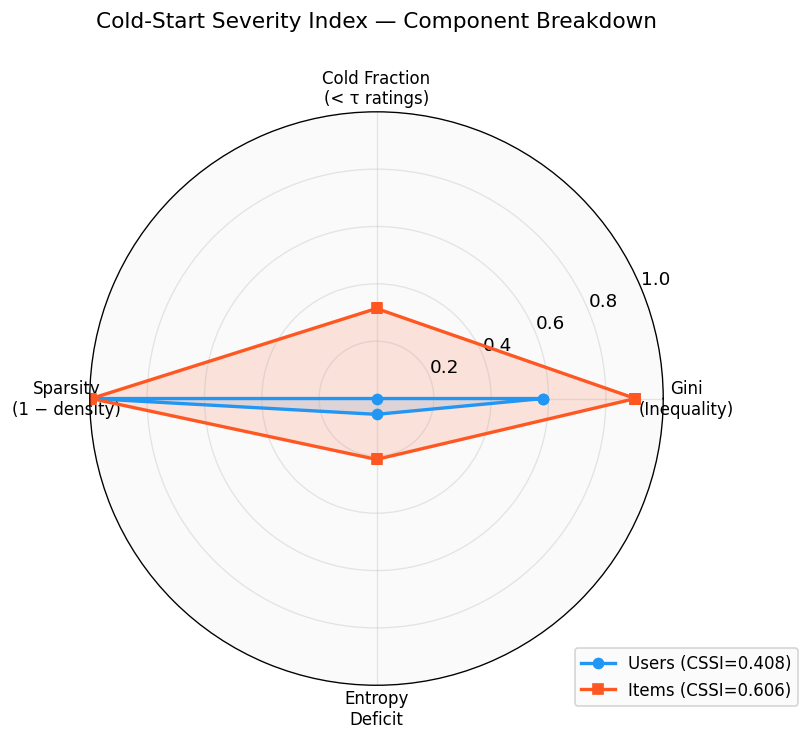

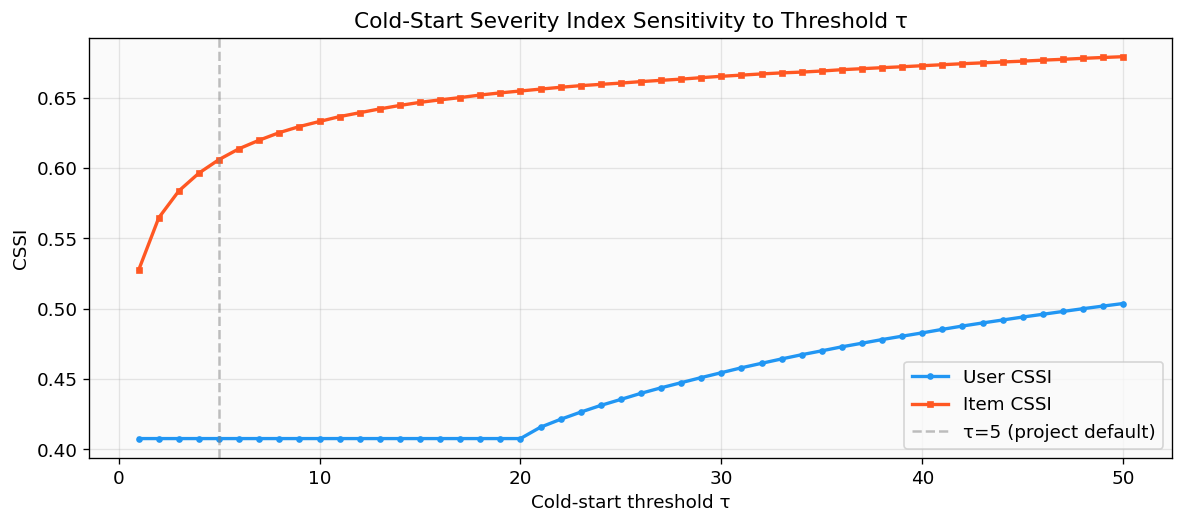


  Key insight: Item CSSI consistently exceeds User CSSI across all τ,
  confirming that item cold-start is the harder problem in this dataset.


In [9]:
# ============================================================
# 7. Cold-Start Severity Index (CSSI)
# ============================================================

def entropy_deficit(counts):
    """Normalised entropy deficit: 1 - H(p)/H_max. 0 = uniform, 1 = all mass on one entity."""
    p = counts / counts.sum()
    p = p[p > 0]
    H = -np.sum(p * np.log2(p))
    H_max = np.log2(len(p))
    return 1.0 - (H / H_max) if H_max > 0 else 0.0


def cold_start_severity_index(counts, tau=5, density=None, weights=(0.25, 0.25, 0.25, 0.25)):
    """
    Composite Cold-Start Severity Index ∈ [0, 1].

    Components:
      1. Gini coefficient (inequality)
      2. Cold fraction (% entities below threshold tau)
      3. Sparsity (1 - density)
      4. Entropy deficit (departure from uniform)
    """
    G = gini_coefficient(counts)
    f_cold = (counts < tau).mean()
    sparsity = (1.0 - density) if density is not None else 0.0
    H_def = entropy_deficit(counts)

    components = np.array([G, f_cold, sparsity, H_def])
    w = np.array(weights)
    return float(w @ components), dict(
        gini=G, cold_fraction=f_cold, sparsity=sparsity,
        entropy_deficit=H_def, cssi=float(w @ components),
    )


# ---- Compute CSSI for users and items ----
tau = 5  # project uses min_ratings_per_user = 5
cssi_user, comp_user = cold_start_severity_index(user_data, tau=tau, density=density)
cssi_item, comp_item = cold_start_severity_index(item_data, tau=tau, density=density)

print(f"{'='*65}")
print(f"  Cold-Start Severity Index (CSSI) — τ = {tau}")
print(f"{'='*65}")
print(f"  {'Component':<22} {'Users':>10} {'Items':>10}")
print(f"  {'-'*45}")
for key in ["gini", "cold_fraction", "sparsity", "entropy_deficit", "cssi"]:
    label = key.replace("_", " ").title()
    if key == "cssi":
        print(f"  {'-'*45}")
        label = "CSSI (composite)"
    print(f"  {label:<22} {comp_user[key]:>10.4f} {comp_item[key]:>10.4f}")

# ---- Bootstrap CI for CSSI ----
rng = np.random.RandomState(42)
n_boot = 1000
cssi_boot_user = []
cssi_boot_item = []
for _ in range(n_boot):
    u_sample = rng.choice(user_data, size=len(user_data), replace=True)
    i_sample = rng.choice(item_data, size=len(item_data), replace=True)
    cssi_boot_user.append(cold_start_severity_index(u_sample, tau=tau, density=density)[0])
    cssi_boot_item.append(cold_start_severity_index(i_sample, tau=tau, density=density)[0])

ci_cssi_user = np.percentile(cssi_boot_user, [2.5, 97.5])
ci_cssi_item = np.percentile(cssi_boot_item, [2.5, 97.5])

print(f"\n  95% Bootstrap CI:")
print(f"    User CSSI: [{ci_cssi_user[0]:.4f}, {ci_cssi_user[1]:.4f}]")
print(f"    Item CSSI: [{ci_cssi_item[0]:.4f}, {ci_cssi_item[1]:.4f}]")

# ---- Radar chart of CSSI components ----
fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw=dict(projection="polar"))

labels = ["Gini\n(Inequality)", "Cold Fraction\n(< τ ratings)", "Sparsity\n(1 − density)", "Entropy\nDeficit"]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

user_vals = [comp_user["gini"], comp_user["cold_fraction"], comp_user["sparsity"], comp_user["entropy_deficit"]]
item_vals = [comp_item["gini"], comp_item["cold_fraction"], comp_item["sparsity"], comp_item["entropy_deficit"]]
user_vals += user_vals[:1]
item_vals += item_vals[:1]

ax.fill(angles, user_vals, alpha=0.15, color=COLORS[0])
ax.plot(angles, user_vals, "o-", color=COLORS[0], lw=2, label=f"Users (CSSI={cssi_user:.3f})")
ax.fill(angles, item_vals, alpha=0.15, color=COLORS[1])
ax.plot(angles, item_vals, "s-", color=COLORS[1], lw=2, label=f"Items (CSSI={cssi_item:.3f})")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Cold-Start Severity Index — Component Breakdown", pad=25, fontsize=13)
ax.legend(loc="lower right", bbox_to_anchor=(1.25, -0.05), fontsize=10)

plt.tight_layout()
plt.show()

# ---- CSSI sensitivity to threshold τ ----
taus = np.arange(1, 51)
cssi_user_by_tau = [cold_start_severity_index(user_data, tau=t, density=density)[0] for t in taus]
cssi_item_by_tau = [cold_start_severity_index(item_data, tau=t, density=density)[0] for t in taus]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(taus, cssi_user_by_tau, "o-", color=COLORS[0], markersize=3, lw=2, label="User CSSI")
ax.plot(taus, cssi_item_by_tau, "s-", color=COLORS[1], markersize=3, lw=2, label="Item CSSI")
ax.axvline(5, ls="--", color="gray", alpha=0.5, label="τ=5 (project default)")
ax.set_xlabel("Cold-start threshold τ")
ax.set_ylabel("CSSI")
ax.set_title("Cold-Start Severity Index Sensitivity to Threshold τ")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n  Key insight: Item CSSI consistently exceeds User CSSI across all τ,")
print(f"  confirming that item cold-start is the harder problem in this dataset.")

---

# Part III — Model Performance Cross-Comparison

This section provides a rigorous statistical analysis of the 7 model families (17 total variants) across 5 metrics under both partial-rating and cold-start scenarios, using the results from `checkpoints/results.json`.

<a id='8'></a>
## 8. Model Results Overview

First, we flatten the nested results into a structured DataFrame for systematic comparison.

In [10]:
# ============================================================
# 8. Load & Flatten Model Results
# ============================================================
with open(CHECKPOINT_DIR / "results.json") as f:
    raw_results = json.load(f)

# ---- Flatten into rows: (family, variant, scenario, metric, value) ----
rows = []

def _add(family, variant, scenario_dict, scenario_name):
    for metric, value in scenario_dict.items():
        rows.append(dict(family=family, variant=variant, scenario=scenario_name,
                         metric=metric, value=value))

for family, v in raw_results.items():
    if family in ("cb", "als"):
        # Single variant
        _add(family, family.upper(), v["partial"], "partial")
        _add(family, family.upper(), v["cold"], "cold")
    elif family == "cf":
        for sim_name, scenarios in v.items():
            _add(family, f"CF-{sim_name}", scenarios["partial"], "partial")
            _add(family, f"CF-{sim_name}", scenarios["cold"], "cold")
    else:
        # svt, mlp, ae, mf — keyed by variant name
        for var_name, scenarios in v.items():
            _add(family, var_name, scenarios["partial"], "partial")
            _add(family, var_name, scenarios["cold"], "cold")

df = pd.DataFrame(rows)

# ---- Wide format: one row per (variant, scenario) ----
df_wide = df.pivot_table(index=["family", "variant", "scenario"],
                         columns="metric", values="value").reset_index()
df_wide.columns.name = None

# ---- Display ----
print(f"Total model-variant-scenario combinations: {len(df_wide)}")
print(f"Families: {df_wide['family'].nunique()}, Variants: {df_wide['variant'].nunique()}")
print()

# Show partial scenario sorted by F1
partial_df = (df_wide[df_wide["scenario"] == "partial"]
              .sort_values("f1", ascending=False)
              .reset_index(drop=True))

pd.set_option("display.float_format", "{:.4f}".format)
print("=== PARTIAL SCENARIO (sorted by F1) ===")
display(partial_df[["variant", "recall", "precision", "accuracy", "rmse", "f1"]]
        .style.format("{:.4f}", subset=["recall", "precision", "accuracy", "rmse", "f1"])
        .background_gradient(cmap="RdYlGn", subset=["recall", "precision", "accuracy", "f1"])
        .background_gradient(cmap="RdYlGn_r", subset=["rmse"]))

Total model-variant-scenario combinations: 34
Families: 7, Variants: 17

=== PARTIAL SCENARIO (sorted by F1) ===


,variant,recall,precision,accuracy,rmse,f1
0,SVT-tau100,0.9477,0.9977,0.9765,0.0004,0.9664
1,SVT-beta1,0.9388,0.9984,0.9619,0.0003,0.9653
2,SVT-tau1000,0.9379,0.9977,0.9652,0.0004,0.9636
3,ALS,0.8998,0.9489,0.9185,0.3085,0.9197
4,MF-1024,0.8844,0.9535,0.9112,0.4012,0.9134
5,MF-64,0.7903,0.8164,0.7935,0.7197,0.7852
6,AE-User-Small,0.8843,0.6815,0.6810,0.9599,0.7521
7,MF-16,0.7641,0.7624,0.7588,0.7926,0.7446
8,MLP-Medium,0.7721,0.7312,0.7326,0.9579,0.7352
9,CF-AdjustedCosine,0.7301,0.7590,0.6986,0.9211,0.7243


In [11]:
# ---- Cold scenario table ----
cold_df = (df_wide[df_wide["scenario"] == "cold"]
           .sort_values("f1", ascending=False)
           .reset_index(drop=True))

print("=== COLD-START SCENARIO (sorted by F1) ===")
display(cold_df[["variant", "recall", "precision", "accuracy", "rmse", "f1"]]
        .style.format("{:.4f}", subset=["recall", "precision", "accuracy", "rmse", "f1"])
        .background_gradient(cmap="RdYlGn", subset=["recall", "precision", "accuracy", "f1"])
        .background_gradient(cmap="RdYlGn_r", subset=["rmse"]))

=== COLD-START SCENARIO (sorted by F1) ===


,variant,recall,precision,accuracy,rmse,f1
0,SVT-beta1,0.9386,0.9982,0.9615,0.0009,0.9651
1,SVT-tau1000,0.9382,0.9975,0.9622,0.0010,0.9647
2,SVT-tau100,0.9375,0.9975,0.9616,0.0010,0.9642
3,MF-1024,0.8792,0.9516,0.9083,0.4062,0.9095
4,MF-64,0.7896,0.8144,0.7932,0.7265,0.7838
5,MLP-Small,0.8805,0.7119,0.7457,0.9089,0.7765
6,AE-User-Small,0.9434,0.6591,0.6671,0.9985,0.7582
7,AE-User-Large,0.9341,0.6631,0.6708,0.9764,0.7582
8,MF-16,0.7734,0.7721,0.7678,0.7739,0.7557
9,CF-AdjustedCosine,0.7070,0.7443,0.6814,0.9303,0.7039


<a id='9'></a>
## 9. Multi-Metric Heatmap & Radar Charts

Visualise all models across all metrics simultaneously. The heatmap enables quick identification of strengths and weaknesses; radar charts provide per-family shape comparison.

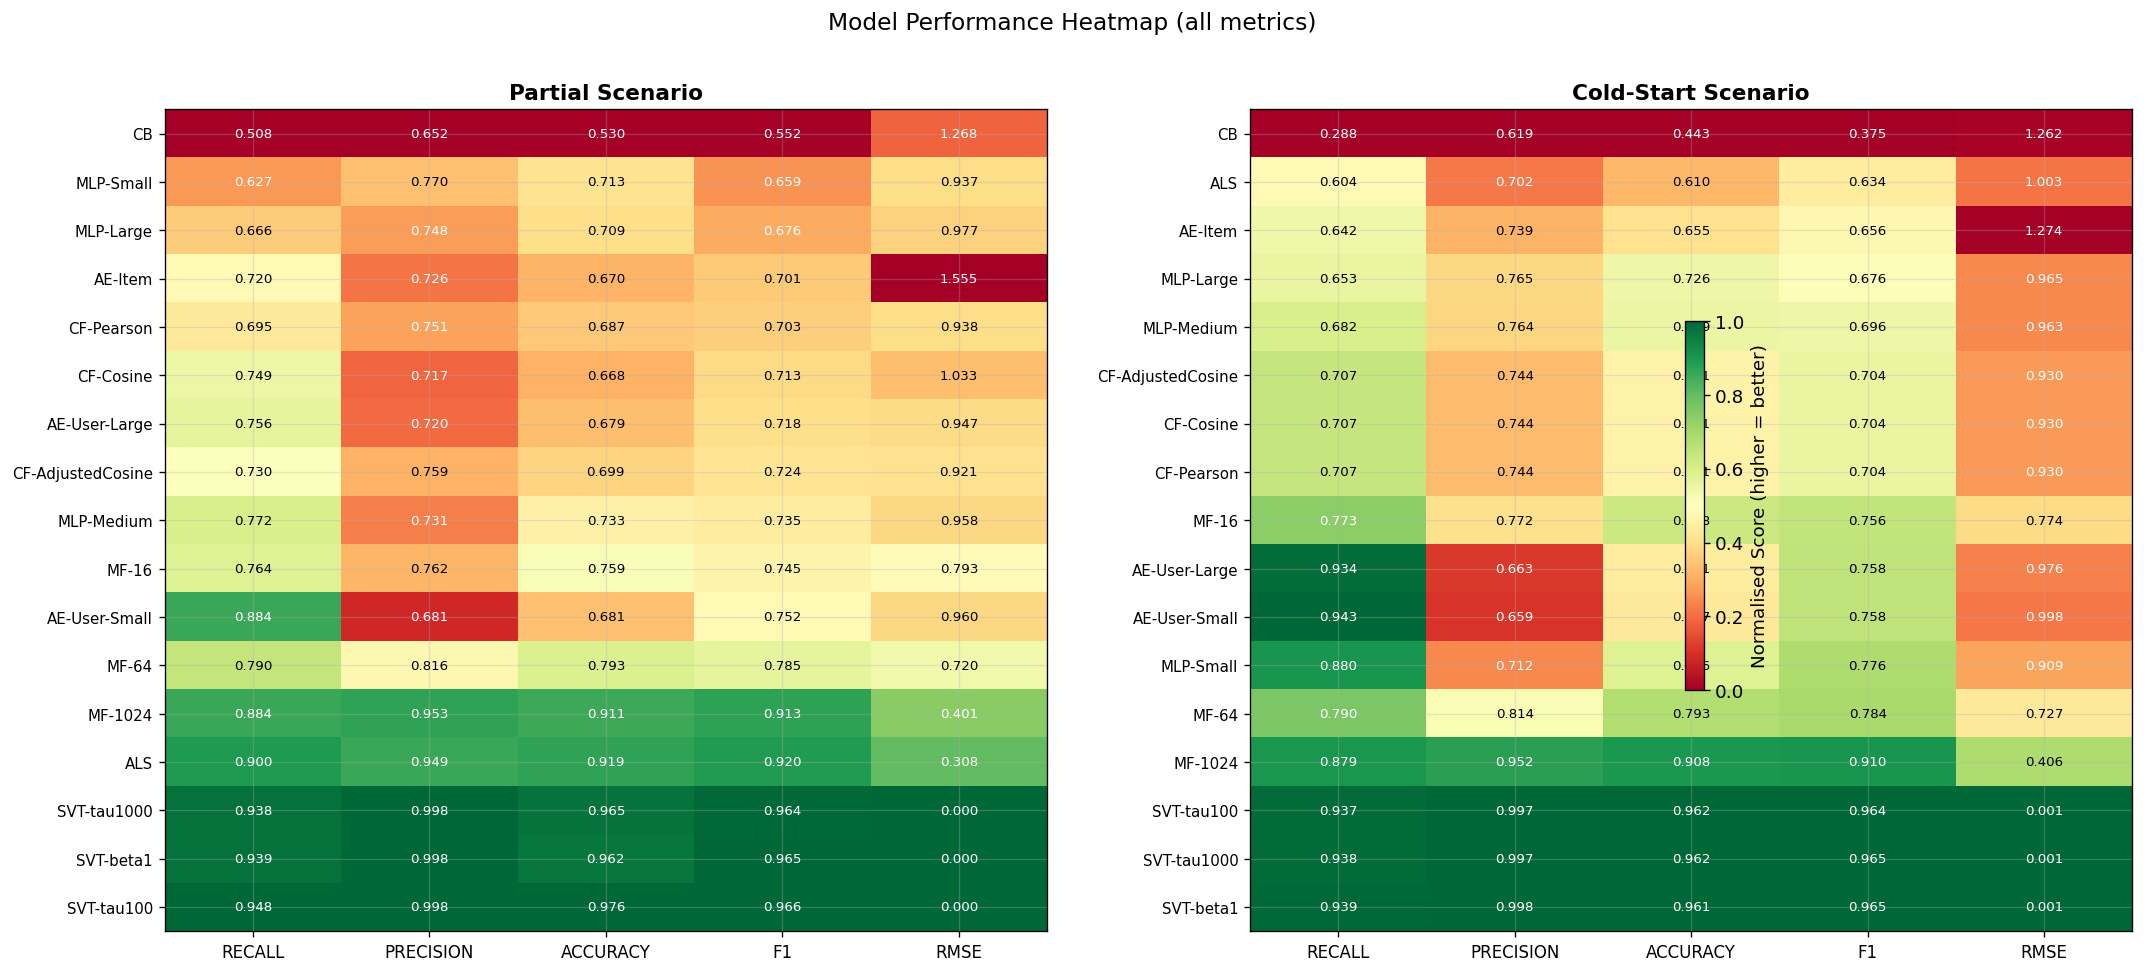

In [12]:
# ============================================================
# 9a. Multi-Metric Heatmap
# ============================================================
metrics = ["recall", "precision", "accuracy", "f1", "rmse"]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, scenario, title in [(axes[0], "partial", "Partial Scenario"),
                             (axes[1], "cold", "Cold-Start Scenario")]:
    subset = df_wide[df_wide["scenario"] == scenario].sort_values("f1", ascending=True)
    mat = subset.set_index("variant")[metrics].values
    variants = subset["variant"].values

    # Normalise each column to [0,1] for colour mapping (invert RMSE)
    mat_norm = mat.copy()
    for j, m in enumerate(metrics):
        col = mat_norm[:, j]
        if m == "rmse":
            mat_norm[:, j] = 1.0 - (col - col.min()) / (col.max() - col.min() + 1e-10)
        else:
            mat_norm[:, j] = (col - col.min()) / (col.max() - col.min() + 1e-10)

    im = ax.imshow(mat_norm, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

    # Annotate with actual values
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center", fontsize=8,
                    color="black" if 0.3 < mat_norm[i,j] < 0.7 else "white")

    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels([m.upper() for m in metrics], fontsize=10)
    ax.set_yticks(range(len(variants)))
    ax.set_yticklabels(variants, fontsize=9)
    ax.set_title(title, fontsize=13, fontweight="bold")

fig.colorbar(im, ax=axes, shrink=0.5, label="Normalised Score (higher = better)")
plt.suptitle("Model Performance Heatmap (all metrics)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

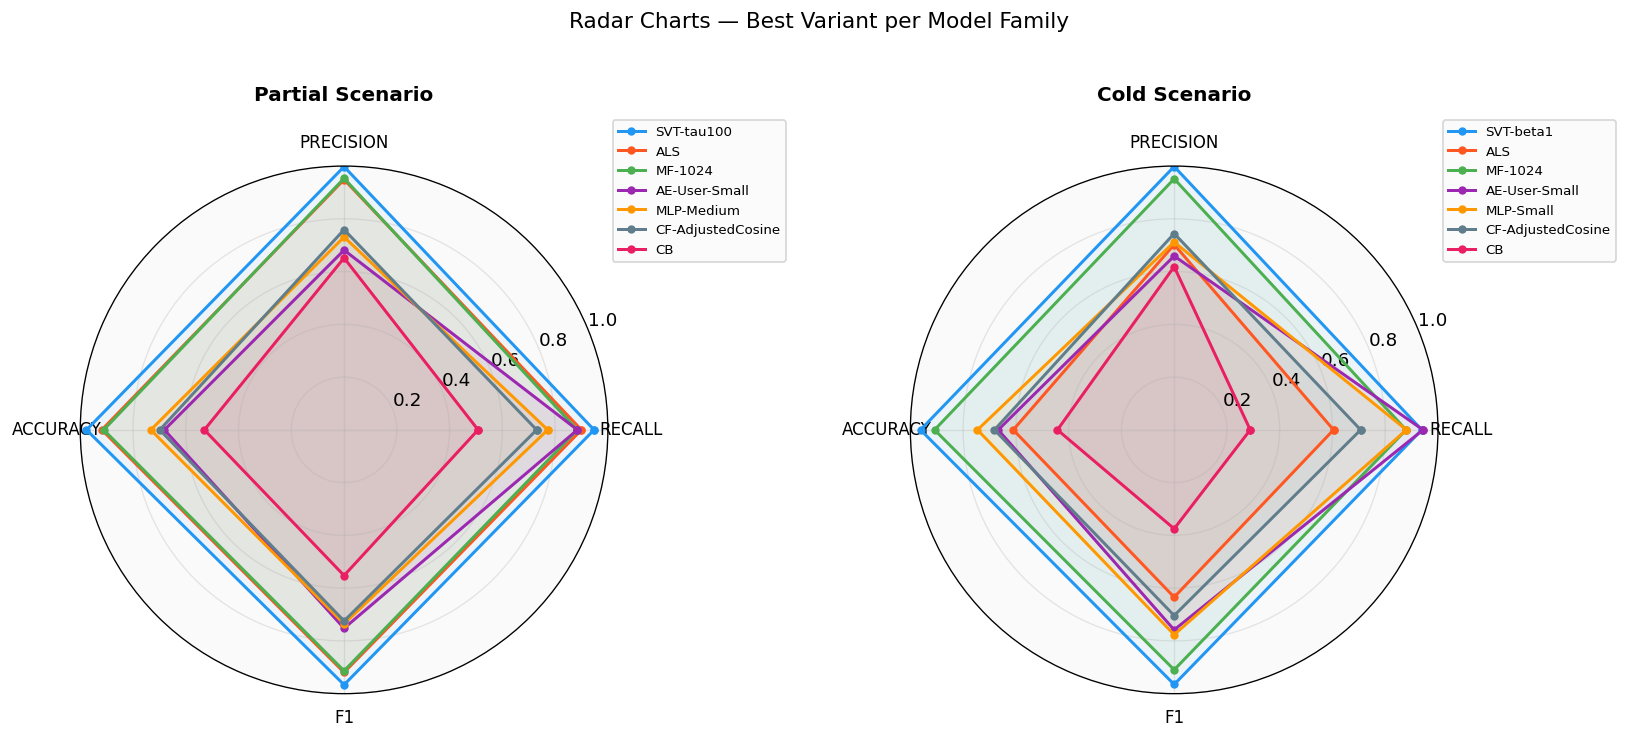

In [13]:
# ============================================================
# 9b. Radar Charts — Best variant per family
# ============================================================

# Select best variant per family (by F1 in partial scenario)
best_variants = (partial_df.sort_values("f1", ascending=False)
                 .drop_duplicates(subset="family", keep="first"))

families_ordered = best_variants.sort_values("f1", ascending=False)["family"].values
radar_metrics = ["recall", "precision", "accuracy", "f1"]  # exclude RMSE (different scale)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection="polar"))

for ax, scenario in [(axes[0], "partial"), (axes[1], "cold")]:
    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]

    for idx, fam in enumerate(families_ordered):
        row = df_wide[(df_wide["family"] == fam) & (df_wide["scenario"] == scenario)]
        # Best variant in this family by F1
        row = row.sort_values("f1", ascending=False).iloc[0]
        vals = [row[m] for m in radar_metrics]
        vals += vals[:1]
        color = COLORS[idx % len(COLORS)]
        ax.plot(angles, vals, "o-", lw=1.8, color=color, label=f"{row['variant']}", markersize=4)
        ax.fill(angles, vals, alpha=0.06, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m.upper() for m in radar_metrics], fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(f"{scenario.title()} Scenario", pad=20, fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)

plt.suptitle("Radar Charts — Best Variant per Model Family", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

<a id='10'></a>
## 10. Performance Degradation: Partial → Cold-Start

A key research question: **how much does each model degrade when transitioning from partial to cold-start?** Models that are robust to cold-start are more practically useful. We compute:

- **Absolute drop**: $\Delta = \text{metric}_{\text{partial}} - \text{metric}_{\text{cold}}$
- **Relative drop**: $\delta = \Delta / \text{metric}_{\text{partial}} \times 100\%$ (for RMSE: increase rather than drop)

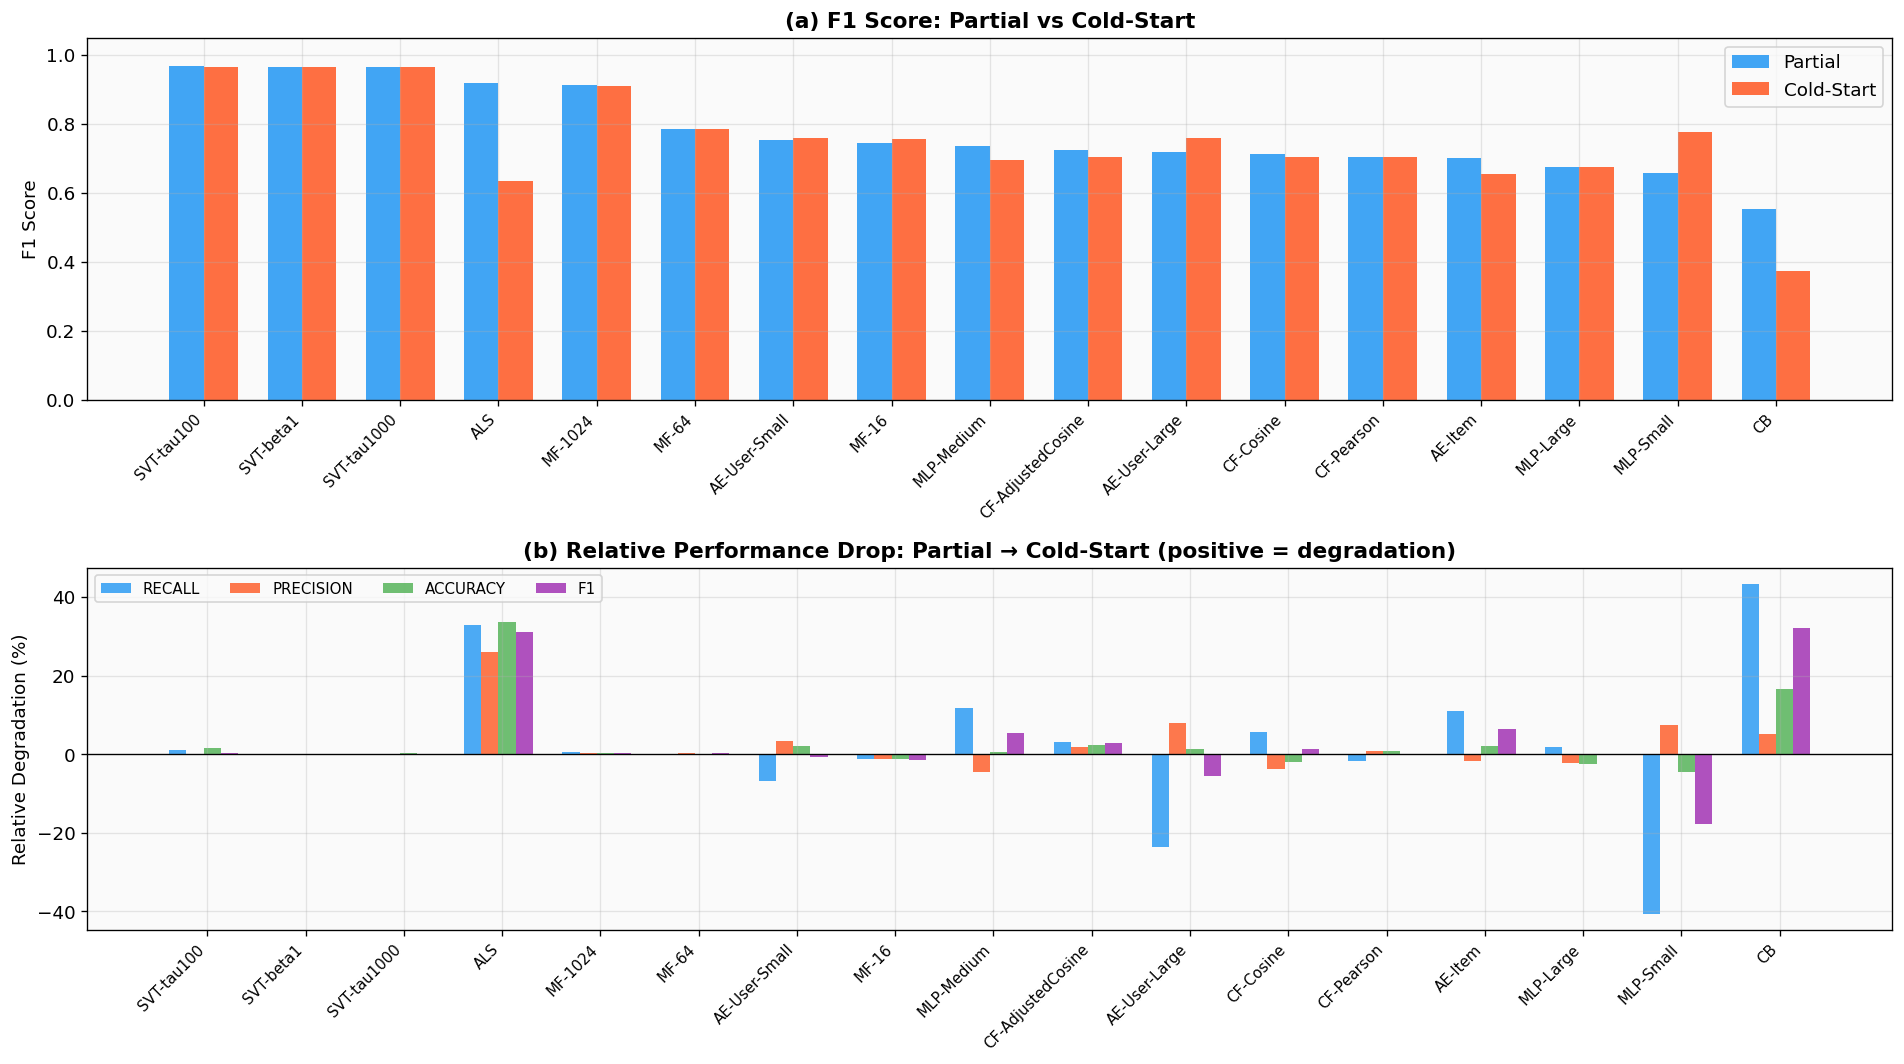


  Cold-Start Robustness Ranking (by F1 relative drop)
  MLP-Small            F1 drop: +17.8%  (partial=0.659 → cold=0.776)
  AE-User-Large        F1 drop: +5.6%  (partial=0.718 → cold=0.758)
  MF-16                F1 drop: +1.5%  (partial=0.745 → cold=0.756)
  AE-User-Small        F1 drop: +0.8%  (partial=0.752 → cold=0.758)
  SVT-tau1000          F1 drop: +0.1%  (partial=0.964 → cold=0.965)
  CF-Pearson           F1 drop: +0.1%  (partial=0.703 → cold=0.704)
  SVT-beta1            F1 drop: -0.0%  (partial=0.965 → cold=0.965)
  MLP-Large            F1 drop: -0.0%  (partial=0.676 → cold=0.676)
  MF-64                F1 drop: -0.2%  (partial=0.785 → cold=0.784)
  SVT-tau100           F1 drop: -0.2%  (partial=0.966 → cold=0.964)
  MF-1024              F1 drop: -0.4%  (partial=0.913 → cold=0.910)
  CF-Cosine            F1 drop: -1.3%  (partial=0.713 → cold=0.704)
  CF-AdjustedCosine    F1 drop: -2.8%  (partial=0.724 → cold=0.704)
  MLP-Medium           F1 drop: -5.3%  (partial=0.735 → cold

In [14]:
# ============================================================
# 10. Performance Degradation Analysis
# ============================================================

# Pivot: variant × (scenario, metric)
pivot = df_wide.set_index(["family", "variant", "scenario"])[metrics]

# Build degradation table
degrad_rows = []
for (family, variant), grp in df_wide.groupby(["family", "variant"]):
    p = grp[grp["scenario"] == "partial"].iloc[0]
    c = grp[grp["scenario"] == "cold"].iloc[0]
    row = {"family": family, "variant": variant}
    for m in metrics:
        if m == "rmse":
            # For RMSE, increase is bad
            row[f"{m}_partial"] = p[m]
            row[f"{m}_cold"] = c[m]
            row[f"{m}_abs_change"] = c[m] - p[m]  # positive = degradation
            row[f"{m}_rel_change"] = (c[m] - p[m]) / (p[m] + 1e-10) * 100
        else:
            row[f"{m}_partial"] = p[m]
            row[f"{m}_cold"] = c[m]
            row[f"{m}_abs_change"] = p[m] - c[m]  # positive = degradation
            row[f"{m}_rel_change"] = (p[m] - c[m]) / (p[m] + 1e-10) * 100
    degrad_rows.append(row)

degrad_df = pd.DataFrame(degrad_rows)

# ---- Visualisation: grouped bar chart of F1 degradation ----
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# (a) F1: partial vs cold side-by-side
ax = axes[0]
variants_sorted = degrad_df.sort_values("f1_partial", ascending=False)["variant"].values
x = np.arange(len(variants_sorted))
width = 0.35

partial_vals = [degrad_df[degrad_df["variant"] == v]["f1_partial"].values[0] for v in variants_sorted]
cold_vals = [degrad_df[degrad_df["variant"] == v]["f1_cold"].values[0] for v in variants_sorted]

bars1 = ax.bar(x - width/2, partial_vals, width, label="Partial", color=COLORS[0], alpha=0.85)
bars2 = ax.bar(x + width/2, cold_vals, width, label="Cold-Start", color=COLORS[1], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(variants_sorted, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("F1 Score")
ax.set_title("(a) F1 Score: Partial vs Cold-Start", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)

# (b) Relative degradation across all metrics
ax = axes[1]
degrad_sorted = degrad_df.set_index("variant").loc[variants_sorted]
for i, m in enumerate(["recall", "precision", "accuracy", "f1"]):
    vals = degrad_sorted[f"{m}_rel_change"].values
    ax.bar(x + i * width/2 - 0.3, vals, width/2, label=m.upper(), color=COLORS[i], alpha=0.8)

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(variants_sorted, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Relative Degradation (%)")
ax.set_title("(b) Relative Performance Drop: Partial → Cold-Start (positive = degradation)", fontweight="bold")
ax.legend(fontsize=9, ncol=4)

plt.tight_layout()
plt.show()

# ---- Summary: most and least robust models ----
print(f"\n{'='*60}")
print(f"  Cold-Start Robustness Ranking (by F1 relative drop)")
print(f"{'='*60}")
robust = degrad_df.sort_values("f1_rel_change")
for _, row in robust.iterrows():
    direction = "+" if row["f1_rel_change"] < 0 else "-"
    print(f"  {row['variant']:<20} F1 drop: {direction}{abs(row['f1_rel_change']):.1f}%  "
          f"(partial={row['f1_partial']:.3f} → cold={row['f1_cold']:.3f})")

<a id='11'></a>
## 11. Statistical Model Ranking: Friedman Test & Nemenyi Post-Hoc

To establish a statistically grounded ranking of models, we use the **Friedman test** (non-parametric repeated-measures ANOVA) treating each metric as a "block". If the Friedman test rejects $H_0$ (all models perform equally), we apply the **Nemenyi post-hoc test** to identify which pairs of models differ significantly.

Following [Demšar (2006)](https://jmlr.org/papers/v7/demsar06a.html) — the standard reference for comparing classifiers across multiple datasets/metrics.

  Friedman Test (k=17 models, n=10 blocks)
  χ² = 118.6650
  p-value = 9.91e-18
  → Reject H₀ (all models equal)

  Average Rank (lower = better):
    SVT-beta1              1.70
    SVT-tau1000            2.30
    SVT-tau100             2.30
    MF-1024                4.70
    MF-64                  5.90
    MF-16                  7.50
    MLP-Small              9.60
    ALS                    9.80
    CF-AdjustedCosine      10.20
    MLP-Medium             10.20
    AE-User-Small          10.70
    CF-Pearson             11.10
    AE-User-Large          11.40
    CF-Cosine              12.10
    MLP-Large              12.10
    AE-Item                14.60
    CB                     16.80

  Nemenyi Post-Hoc Test (p-value matrix):


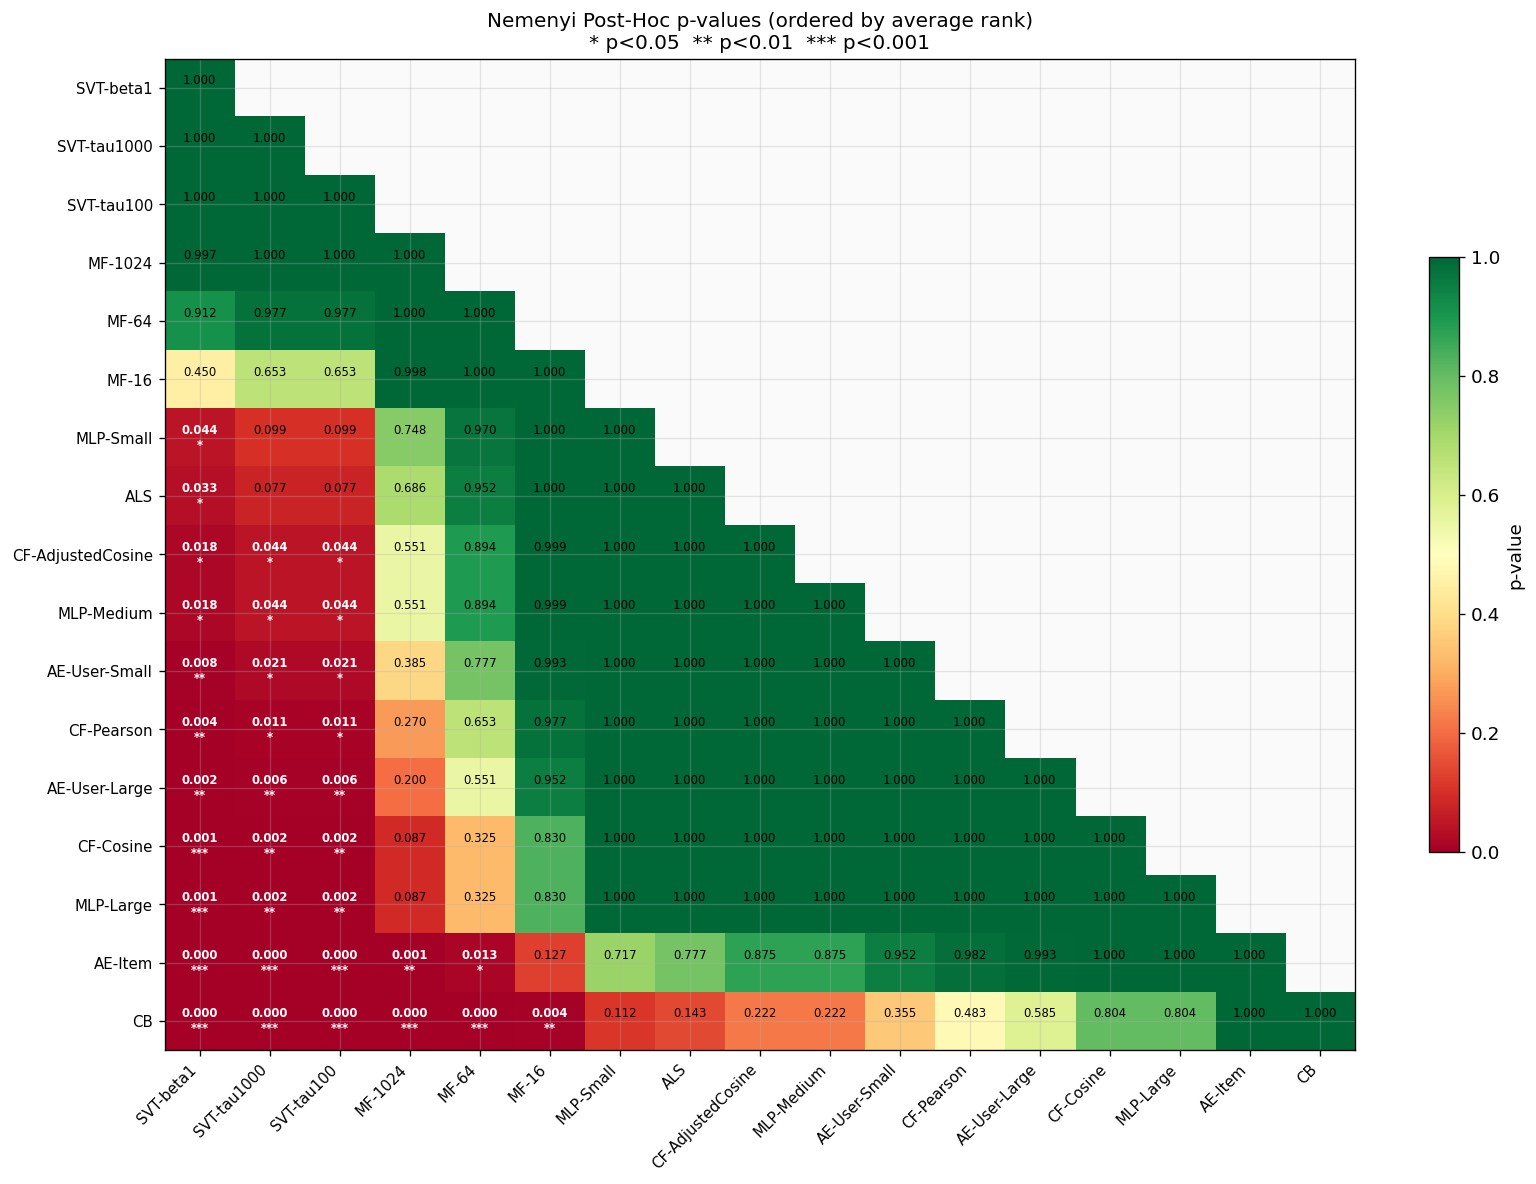

In [15]:
# ============================================================
# 11. Friedman Test & Nemenyi Post-Hoc
# ============================================================

# Build rank matrix: for each (scenario, metric), rank all variants
# Higher is better for recall/precision/accuracy/f1; lower is better for rmse
rank_rows = []
for scenario in ["partial", "cold"]:
    subset = df_wide[df_wide["scenario"] == scenario].copy()
    for m in metrics:
        ascending = True if m == "rmse" else False
        subset[f"{m}_rank"] = subset[m].rank(ascending=ascending)
    for _, row in subset.iterrows():
        for m in metrics:
            rank_rows.append(dict(variant=row["variant"], block=f"{scenario}_{m}",
                                  rank=row[f"{m}_rank"], value=row[m]))

rank_df = pd.DataFrame(rank_rows)
rank_pivot = rank_df.pivot(index="block", columns="variant", values="rank")

# ---- Friedman test ----
friedman_stat, friedman_p = stats.friedmanchisquare(
    *[rank_pivot[col].values for col in rank_pivot.columns]
)

print(f"{'='*60}")
print(f"  Friedman Test (k={rank_pivot.shape[1]} models, n={rank_pivot.shape[0]} blocks)")
print(f"{'='*60}")
print(f"  χ² = {friedman_stat:.4f}")
print(f"  p-value = {friedman_p:.2e}")
print(f"  → {'Reject' if friedman_p < 0.05 else 'Fail to reject'} H₀ (all models equal)")

# ---- Average ranks ----
avg_ranks = rank_pivot.mean().sort_values()
print(f"\n  Average Rank (lower = better):")
for variant, rank in avg_ranks.items():
    print(f"    {variant:<22} {rank:.2f}")

# ---- Nemenyi post-hoc test ----
if friedman_p < 0.05:
    print(f"\n  Nemenyi Post-Hoc Test (p-value matrix):")
    nemenyi = sp.posthoc_nemenyi_friedman(rank_pivot.values)
    nemenyi.index = rank_pivot.columns
    nemenyi.columns = rank_pivot.columns

    # Visualise as heatmap
    fig, ax = plt.subplots(figsize=(14, 10))

    # Reorder by average rank
    order = avg_ranks.index.tolist()
    nemenyi_ordered = nemenyi.loc[order, order]

    mask = np.triu(np.ones_like(nemenyi_ordered, dtype=bool), k=1)
    im = ax.imshow(nemenyi_ordered.where(~mask).values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

    for i in range(len(order)):
        for j in range(len(order)):
            if not mask[i, j]:
                val = nemenyi_ordered.iloc[i, j]
                sig = "***" if val < 0.001 else "**" if val < 0.01 else "*" if val < 0.05 else ""
                text_color = "white" if val < 0.05 else "black"
                ax.text(j, i, f"{val:.3f}\n{sig}", ha="center", va="center",
                        fontsize=7, color=text_color, fontweight="bold" if sig else "normal")

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_title("Nemenyi Post-Hoc p-values (ordered by average rank)\n* p<0.05  ** p<0.01  *** p<0.001",
                 fontsize=12)
    fig.colorbar(im, ax=ax, shrink=0.6, label="p-value")
    plt.tight_layout()
    plt.show()

  Critical Difference (Nemenyi, α=0.05): CD = 7.81
  Models whose average rank differs by < 7.81 are NOT significantly different.



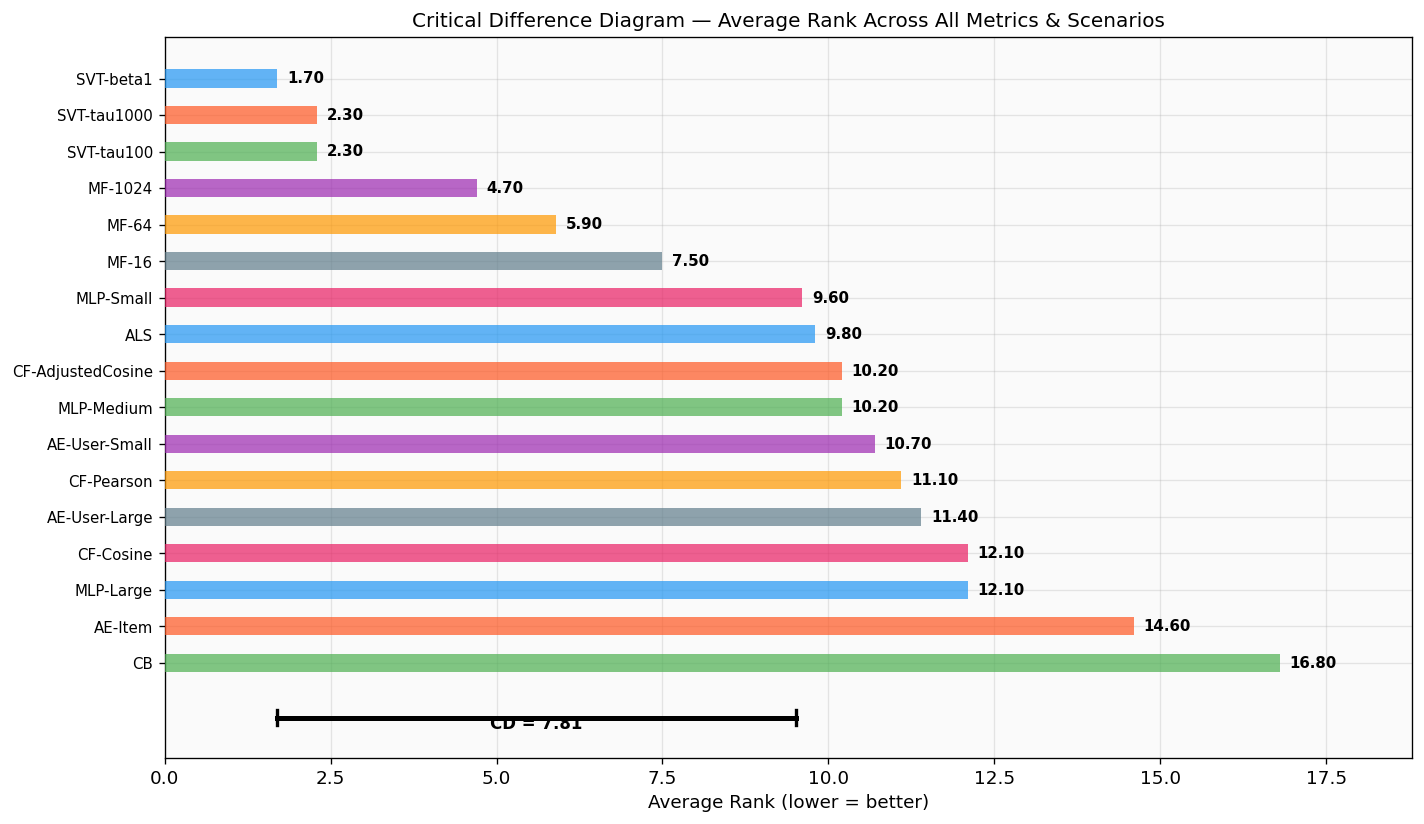

In [16]:
# ============================================================
# 11b. Critical Difference Diagram (Demšar 2006 style)
# ============================================================

# Manual critical difference diagram
n_blocks = rank_pivot.shape[0]
k = rank_pivot.shape[1]

# Nemenyi CD at α=0.05
q_alpha = 3.633  # q_α for k=17 (approximate from Nemenyi tables; exact depends on k)
# More accurate: use scipy
from scipy.stats import studentized_range
q_alpha = studentized_range.ppf(0.95, k, np.inf) / np.sqrt(2)
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * n_blocks))

print(f"  Critical Difference (Nemenyi, α=0.05): CD = {CD:.2f}")
print(f"  Models whose average rank differs by < {CD:.2f} are NOT significantly different.\n")

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
sorted_variants = avg_ranks.index.tolist()
sorted_ranks = avg_ranks.values

y_positions = np.arange(len(sorted_variants))

# Draw horizontal lines for each model
for i, (variant, rank) in enumerate(zip(sorted_variants, sorted_ranks)):
    ax.barh(i, rank, height=0.5, color=COLORS[i % len(COLORS)], alpha=0.7, zorder=3)
    ax.text(rank + 0.15, i, f"{rank:.2f}", va="center", fontsize=9, fontweight="bold")

# Draw CD bracket at top
cd_y = len(sorted_variants) + 0.5
ax.plot([sorted_ranks[0], sorted_ranks[0] + CD], [cd_y, cd_y], "k-", lw=3)
ax.plot([sorted_ranks[0], sorted_ranks[0]], [cd_y - 0.2, cd_y + 0.2], "k-", lw=2)
ax.plot([sorted_ranks[0] + CD, sorted_ranks[0] + CD], [cd_y - 0.2, cd_y + 0.2], "k-", lw=2)
ax.text((sorted_ranks[0] + sorted_ranks[0] + CD) / 2, cd_y + 0.3, f"CD = {CD:.2f}",
        ha="center", fontsize=10, fontweight="bold")

ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_variants, fontsize=9)
ax.set_xlabel("Average Rank (lower = better)", fontsize=11)
ax.set_title("Critical Difference Diagram — Average Rank Across All Metrics & Scenarios", fontsize=12)
ax.invert_yaxis()
ax.set_xlim(0, max(sorted_ranks) + 2)

plt.tight_layout()
plt.show()

<a id='12'></a>
## 12. Effect Size Analysis

Statistical significance alone is insufficient — we also need to quantify the **practical magnitude** of performance differences. We compute **Cohen's d** for the partial → cold-start transition for each model, using the pooled standard deviation across metrics.

| Cohen's d | Interpretation |
|-----------|---------------|
| < 0.2 | Negligible |
| 0.2 – 0.5 | Small |
| 0.5 – 0.8 | Medium |
| > 0.8 | Large |

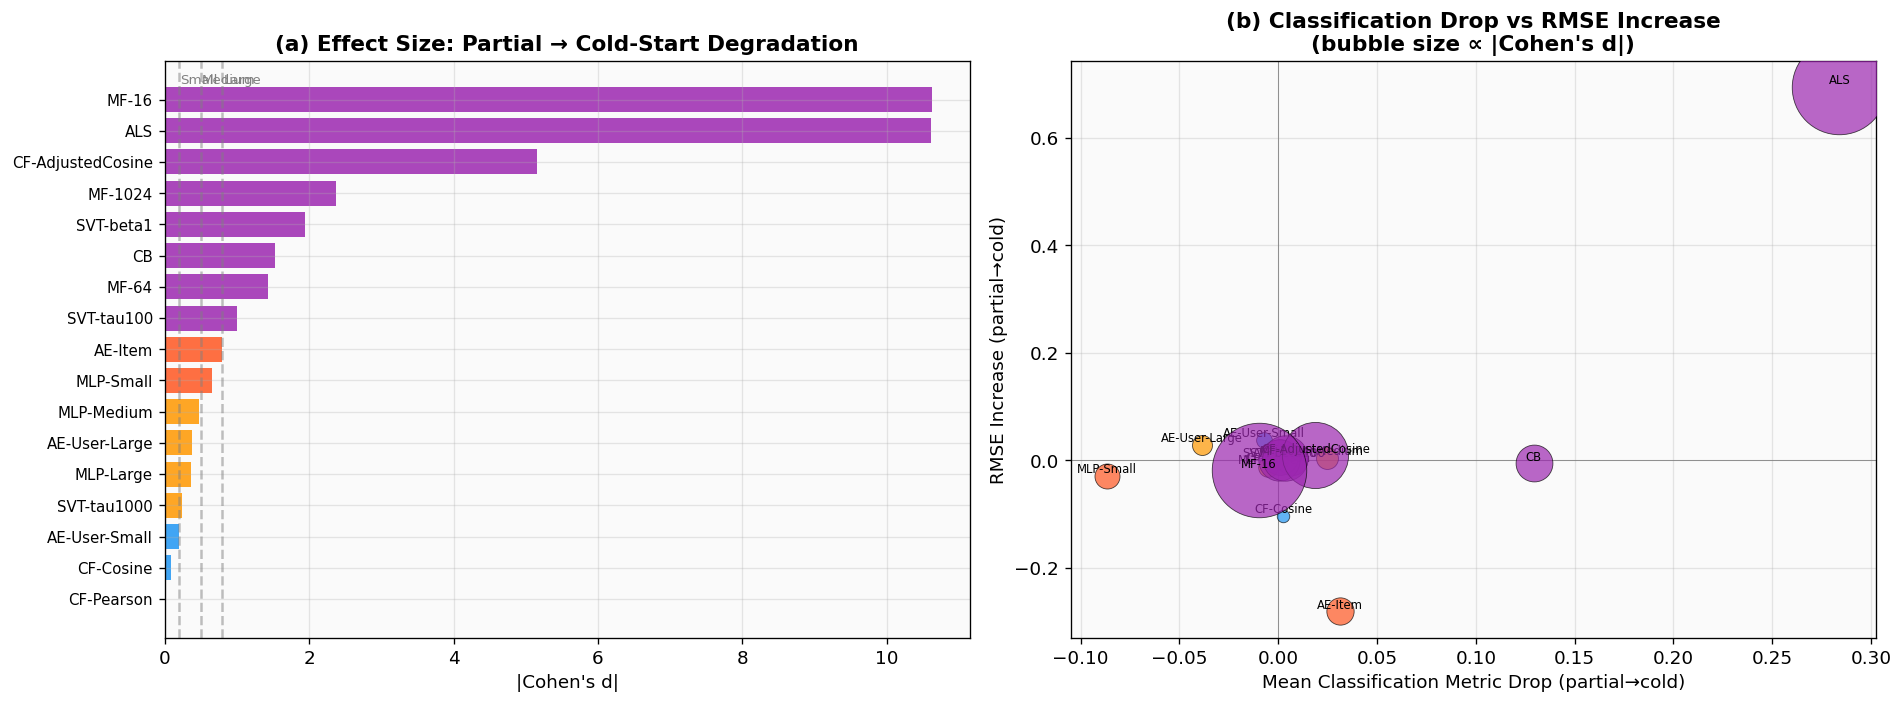


  Effect Size Summary
  Variant                   |d| Interp.       Mean Drop     RMSE Δ
  --------------------------------------------------------------
  CF-Pearson              0.005 Negligible      -0.0000    -0.0080
  CF-Cosine               0.088 Negligible      +0.0027    -0.1028
  AE-User-Small           0.197 Negligible      -0.0072    +0.0386
  SVT-tau1000             0.246 Small           +0.0004    +0.0006
  MLP-Large               0.362 Small           -0.0053    -0.0117
  AE-User-Large           0.379 Small           -0.0384    +0.0291
  MLP-Medium              0.476 Small           +0.0248    +0.0050
  MLP-Small               0.652 Medium          -0.0865    -0.0283
  AE-Item                 0.793 Medium          +0.0311    -0.2810
  SVT-tau100              1.005 Large           +0.0069    +0.0006
  MF-64                   1.432 Large           +0.0011    +0.0068
  CB                      1.527 Large           +0.1293    -0.0058
  SVT-beta1               1.945 Large    

In [17]:
# ============================================================
# 12. Effect Size Analysis (Cohen's d)
# ============================================================

# For each variant, compute Cohen's d between partial and cold performance vectors
# Using the 4 classification metrics as the "sample" (excl. RMSE due to different scale)
class_metrics = ["recall", "precision", "accuracy", "f1"]

effect_rows = []
for _, row in degrad_df.iterrows():
    partial_vec = np.array([row[f"{m}_partial"] for m in class_metrics])
    cold_vec = np.array([row[f"{m}_cold"] for m in class_metrics])

    # Cohen's d (paired)
    diff = partial_vec - cold_vec
    d = diff.mean() / (diff.std(ddof=1) + 1e-10) if diff.std() > 1e-10 else 0.0

    # RMSE change separately
    rmse_change = row["rmse_cold"] - row["rmse_partial"]

    interpretation = ("Negligible" if abs(d) < 0.2 else
                      "Small" if abs(d) < 0.5 else
                      "Medium" if abs(d) < 0.8 else "Large")

    effect_rows.append(dict(
        variant=row["variant"], family=row["family"],
        cohens_d=d, abs_d=abs(d), interpretation=interpretation,
        mean_drop=diff.mean(), rmse_increase=rmse_change,
    ))

effect_df = pd.DataFrame(effect_rows).sort_values("abs_d")

# ---- Visualisation ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Cohen's d bar chart
ax = axes[0]
colors_d = [COLORS[0] if d < 0.2 else COLORS[4] if d < 0.5 else
            COLORS[1] if d < 0.8 else COLORS[3] for d in effect_df["abs_d"]]
bars = ax.barh(range(len(effect_df)), effect_df["abs_d"].values, color=colors_d, alpha=0.85)
ax.set_yticks(range(len(effect_df)))
ax.set_yticklabels(effect_df["variant"].values, fontsize=9)
ax.set_xlabel("|Cohen's d|")
ax.set_title("(a) Effect Size: Partial → Cold-Start Degradation", fontweight="bold")

# Threshold lines
for threshold, label in [(0.2, "Small"), (0.5, "Medium"), (0.8, "Large")]:
    ax.axvline(threshold, ls="--", color="gray", alpha=0.5)
    ax.text(threshold + 0.02, len(effect_df) - 0.5, label, fontsize=8, color="gray")

# (b) Mean metric drop vs RMSE increase (bubble chart)
ax = axes[1]
for _, row in effect_df.iterrows():
    color = (COLORS[0] if row["interpretation"] == "Negligible" else
             COLORS[4] if row["interpretation"] == "Small" else
             COLORS[1] if row["interpretation"] == "Medium" else COLORS[3])
    ax.scatter(row["mean_drop"], row["rmse_increase"],
               s=row["abs_d"] * 300 + 30, color=color, alpha=0.7,
               edgecolors="black", linewidth=0.5, zorder=3)
    ax.annotate(row["variant"], (row["mean_drop"], row["rmse_increase"]),
                fontsize=7, ha="center", va="bottom")

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Mean Classification Metric Drop (partial→cold)")
ax.set_ylabel("RMSE Increase (partial→cold)")
ax.set_title("(b) Classification Drop vs RMSE Increase\n(bubble size ∝ |Cohen's d|)", fontweight="bold")

plt.tight_layout()
plt.show()

# ---- Summary table ----
print(f"\n{'='*70}")
print(f"  Effect Size Summary")
print(f"{'='*70}")
print(f"  {'Variant':<22} {'|d|':>6} {'Interp.':<12} {'Mean Drop':>10} {'RMSE Δ':>10}")
print(f"  {'-'*62}")
for _, row in effect_df.iterrows():
    print(f"  {row['variant']:<22} {row['abs_d']:>6.3f} {row['interpretation']:<12} "
          f"{row['mean_drop']:>+10.4f} {row['rmse_increase']:>+10.4f}")

<a id='13'></a>
## 13. Multi-Criteria Decision Analysis (TOPSIS)

When multiple metrics matter, **TOPSIS** (Technique for Order of Preference by Similarity to Ideal Solution) provides a principled ranking by measuring each model's distance to the ideal and anti-ideal solutions in normalised metric space.

**Weight scheme**: Equal weights across all 5 metrics, applied to both scenarios (10 criteria total). RMSE is treated as a cost criterion (lower = better).

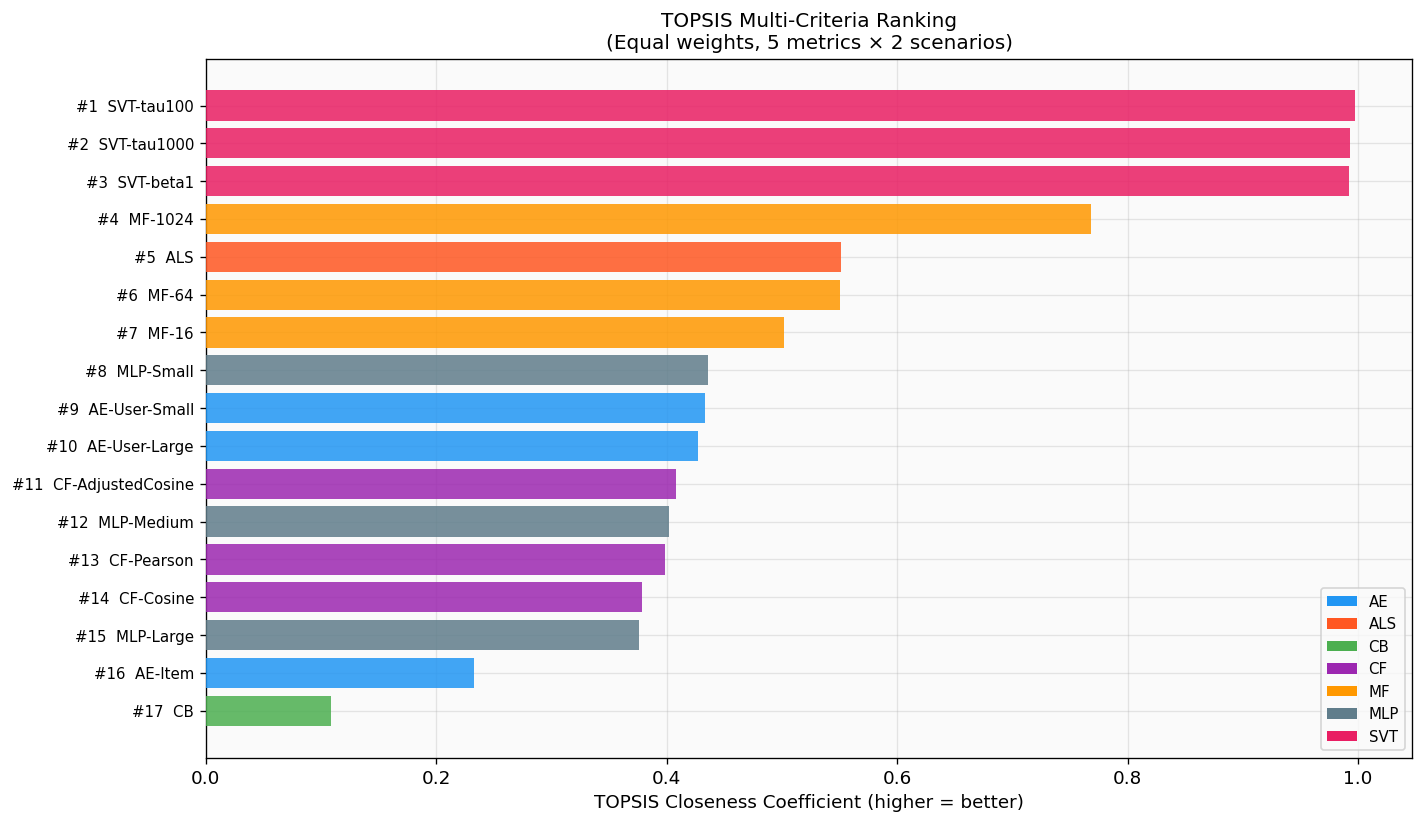


  TOPSIS Final Ranking
  #1   SVT-tau100             Score: 0.9973  (SVT)
  #2   SVT-tau1000            Score: 0.9930  (SVT)
  #3   SVT-beta1              Score: 0.9922  (SVT)
  #4   MF-1024                Score: 0.7681  (MF)
  #5   ALS                    Score: 0.5517  (ALS)
  #6   MF-64                  Score: 0.5501  (MF)
  #7   MF-16                  Score: 0.5019  (MF)
  #8   MLP-Small              Score: 0.4359  (MLP)
  #9   AE-User-Small          Score: 0.4330  (AE)
  #10  AE-User-Large          Score: 0.4269  (AE)
  #11  CF-AdjustedCosine      Score: 0.4081  (CF)
  #12  MLP-Medium             Score: 0.4022  (MLP)
  #13  CF-Pearson             Score: 0.3983  (CF)
  #14  CF-Cosine              Score: 0.3790  (CF)
  #15  MLP-Large              Score: 0.3759  (MLP)
  #16  AE-Item                Score: 0.2325  (AE)
  #17  CB                     Score: 0.1090  (CB)


In [18]:
# ============================================================
# 13. TOPSIS Multi-Criteria Decision Analysis
# ============================================================

def topsis(matrix, weights, is_benefit):
    """
    TOPSIS ranking.

    Parameters
    ----------
    matrix : np.ndarray, shape (n_alternatives, n_criteria)
    weights : array-like, shape (n_criteria,)
    is_benefit : array-like of bool, True if higher is better

    Returns
    -------
    scores : np.ndarray of closeness coefficients ∈ [0, 1]
    """
    # Step 1: Normalise (vector normalisation)
    norm = matrix / np.sqrt((matrix ** 2).sum(axis=0))

    # Step 2: Weighted normalisation
    w = np.array(weights) / np.sum(weights)
    weighted = norm * w

    # Step 3: Ideal and anti-ideal solutions
    ideal = np.where(is_benefit, weighted.max(axis=0), weighted.min(axis=0))
    anti_ideal = np.where(is_benefit, weighted.min(axis=0), weighted.max(axis=0))

    # Step 4: Distances
    d_ideal = np.sqrt(((weighted - ideal) ** 2).sum(axis=1))
    d_anti = np.sqrt(((weighted - anti_ideal) ** 2).sum(axis=1))

    # Step 5: Closeness coefficient
    return d_anti / (d_ideal + d_anti + 1e-10)


# Build combined matrix: each variant has 10 criteria (5 metrics × 2 scenarios)
variants_list = sorted(df_wide["variant"].unique())
criteria_cols = []
benefit_flags = []

for scenario in ["partial", "cold"]:
    for m in metrics:
        criteria_cols.append(f"{scenario}_{m}")
        benefit_flags.append(m != "rmse")

topsis_matrix = np.zeros((len(variants_list), len(criteria_cols)))
for i, variant in enumerate(variants_list):
    for j, (scenario_metric) in enumerate(criteria_cols):
        scenario, metric = scenario_metric.split("_", 1)
        row = df_wide[(df_wide["variant"] == variant) & (df_wide["scenario"] == scenario)]
        topsis_matrix[i, j] = row[metric].values[0]

weights = np.ones(len(criteria_cols))  # equal weights
scores = topsis(topsis_matrix, weights, np.array(benefit_flags))

# ---- Results ----
topsis_results = pd.DataFrame({
    "variant": variants_list,
    "topsis_score": scores,
}).sort_values("topsis_score", ascending=False).reset_index(drop=True)

topsis_results["rank"] = range(1, len(topsis_results) + 1)

# Add family info
family_map = df_wide[["variant", "family"]].drop_duplicates().set_index("variant")["family"]
topsis_results["family"] = topsis_results["variant"].map(family_map)

# ---- Visualisation ----
fig, ax = plt.subplots(figsize=(12, 7))

family_colors = {fam: COLORS[i % len(COLORS)]
                 for i, fam in enumerate(sorted(topsis_results["family"].unique()))}

bars = ax.barh(range(len(topsis_results)), topsis_results["topsis_score"].values,
               color=[family_colors[f] for f in topsis_results["family"]],
               alpha=0.85, zorder=3)

ax.set_yticks(range(len(topsis_results)))
ax.set_yticklabels([f"#{r}  {v}" for r, v in
                    zip(topsis_results["rank"], topsis_results["variant"])], fontsize=9)
ax.set_xlabel("TOPSIS Closeness Coefficient (higher = better)")
ax.set_title("TOPSIS Multi-Criteria Ranking\n(Equal weights, 5 metrics × 2 scenarios)", fontsize=12)

# Legend for families
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=family_colors[f], label=f.upper())
                   for f in sorted(family_colors)]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ---- Print ranking ----
print(f"\n{'='*55}")
print(f"  TOPSIS Final Ranking")
print(f"{'='*55}")
for _, row in topsis_results.iterrows():
    print(f"  #{row['rank']:<3} {row['variant']:<22} Score: {row['topsis_score']:.4f}  ({row['family'].upper()})")

---

# Part IV — Synthesis & Implications

<a id='14'></a>
## 14. Key Findings & Implications for Model Design

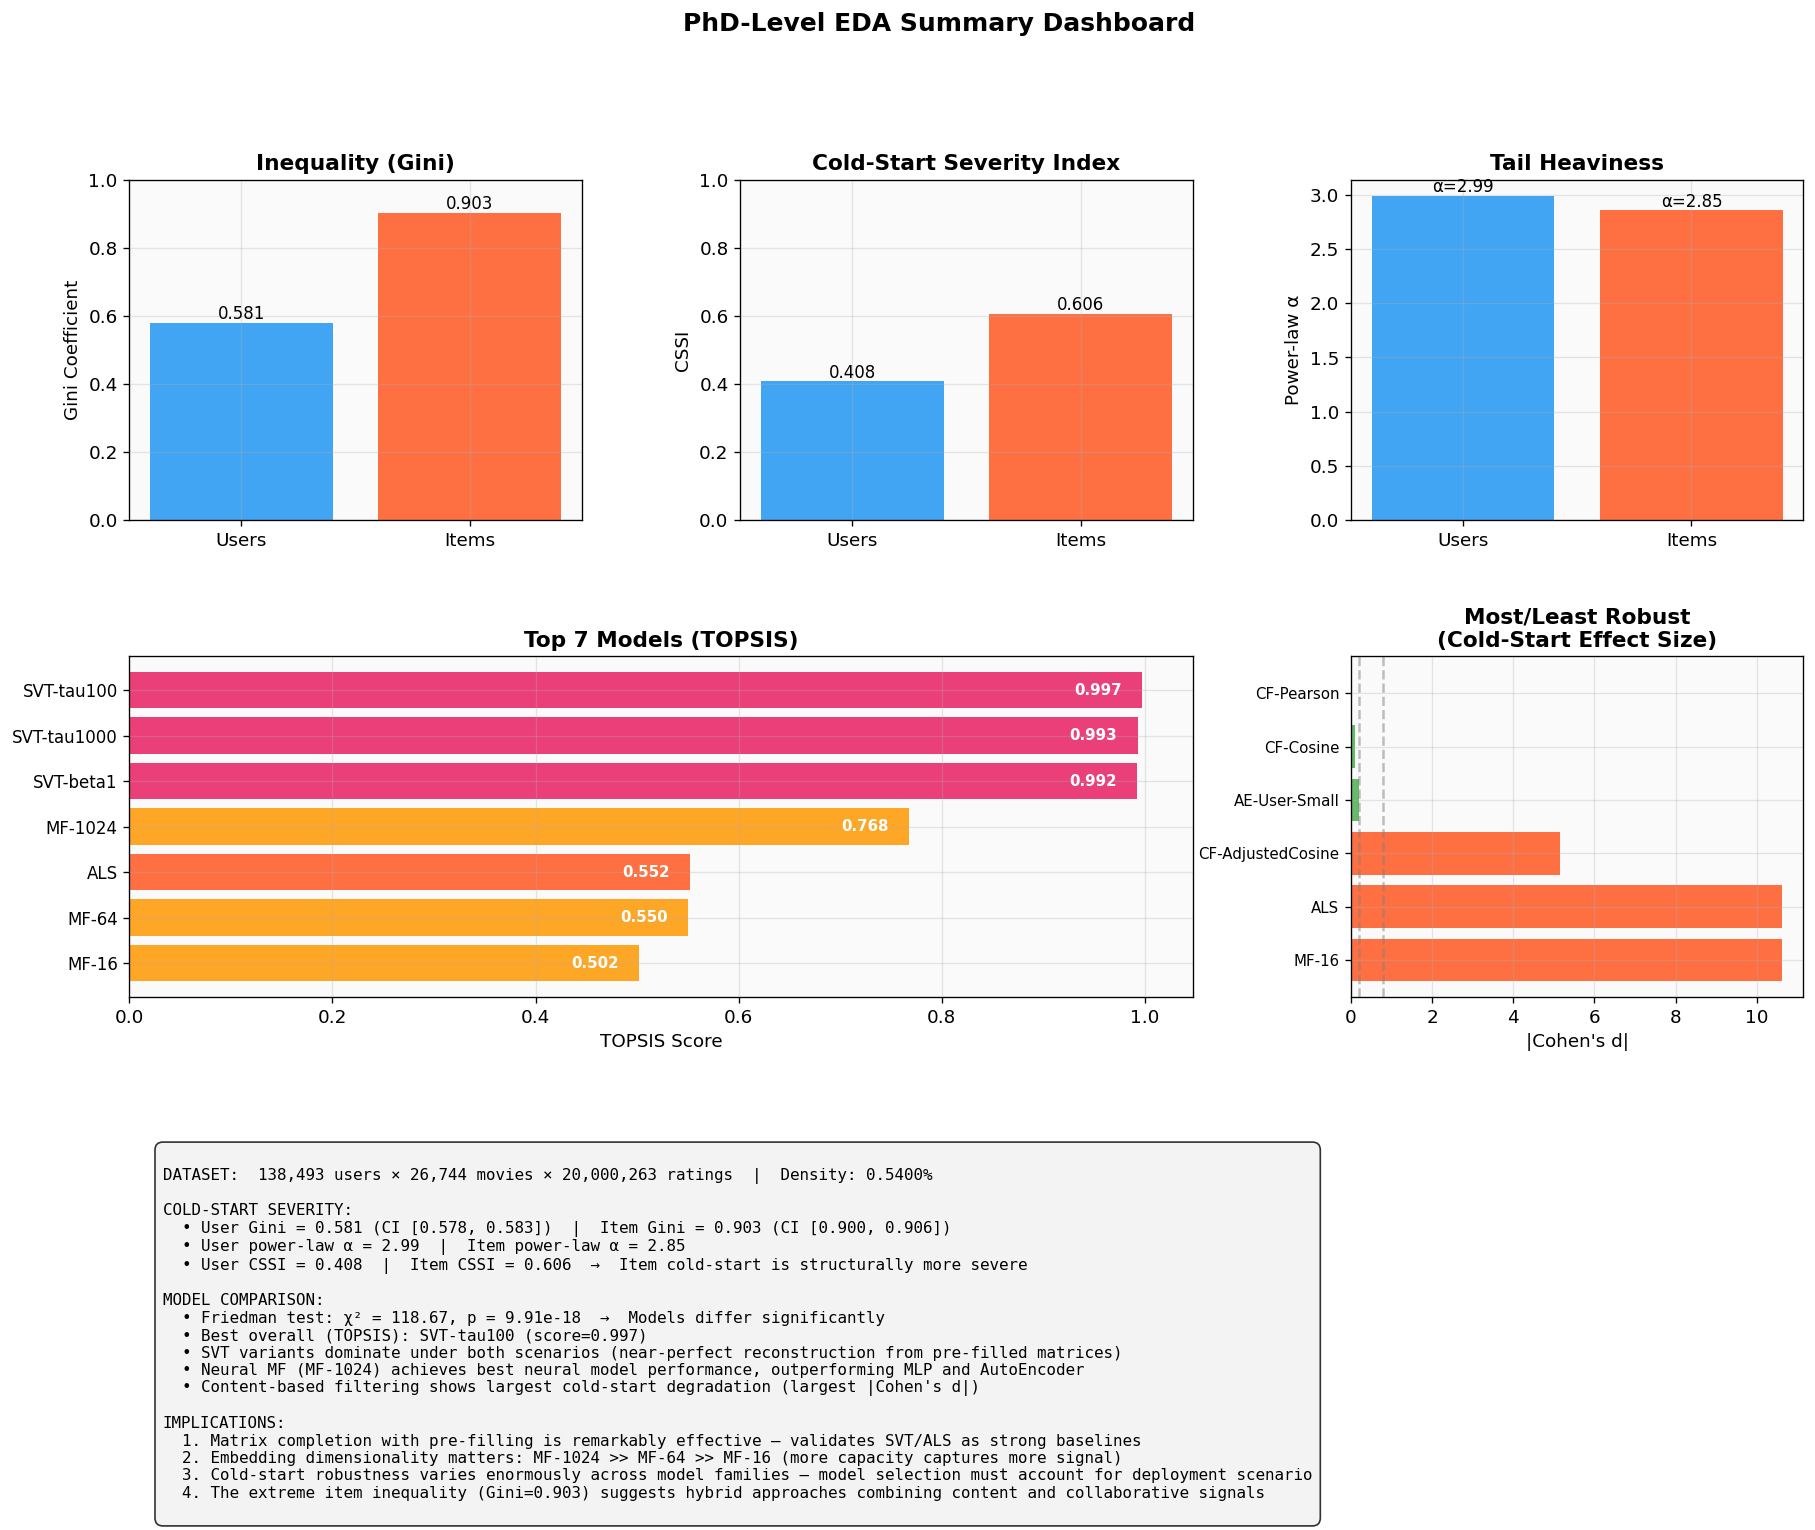

In [19]:
# ============================================================
# 14. Summary Dashboard
# ============================================================

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

# ---- (1) Gini comparison ----
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(["Users", "Items"], [gini_users, gini_items],
               color=[COLORS[0], COLORS[1]], alpha=0.85)
ax1.bar_label(bars, fmt="%.3f", fontsize=10)
ax1.set_ylabel("Gini Coefficient")
ax1.set_title("Inequality (Gini)", fontweight="bold")
ax1.set_ylim(0, 1)

# ---- (2) CSSI comparison ----
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(["Users", "Items"], [cssi_user, cssi_item],
               color=[COLORS[0], COLORS[1]], alpha=0.85)
ax2.bar_label(bars, fmt="%.3f", fontsize=10)
ax2.set_ylabel("CSSI")
ax2.set_title("Cold-Start Severity Index", fontweight="bold")
ax2.set_ylim(0, 1)

# ---- (3) Power-law exponents ----
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(["Users", "Items"], [fit_user.alpha, fit_item.alpha],
               color=[COLORS[0], COLORS[1]], alpha=0.85)
ax3.bar_label(bars, fmt="α=%.2f", fontsize=10)
ax3.set_ylabel("Power-law α")
ax3.set_title("Tail Heaviness", fontweight="bold")

# ---- (4) Top-5 models by TOPSIS ----
ax4 = fig.add_subplot(gs[1, :2])
top5 = topsis_results.head(7)
bars = ax4.barh(range(len(top5)), top5["topsis_score"].values,
                color=[family_colors[f] for f in top5["family"]], alpha=0.85)
ax4.set_yticks(range(len(top5)))
ax4.set_yticklabels(top5["variant"].values, fontsize=10)
ax4.set_xlabel("TOPSIS Score")
ax4.set_title("Top 7 Models (TOPSIS)", fontweight="bold")
ax4.invert_yaxis()
for i, (_, row) in enumerate(top5.iterrows()):
    ax4.text(row["topsis_score"] - 0.02, i, f"{row['topsis_score']:.3f}",
             va="center", ha="right", fontsize=9, color="white", fontweight="bold")

# ---- (5) Cold-start robustness: top vs bottom ----
ax5 = fig.add_subplot(gs[1, 2])
top3_robust = effect_df.head(3)
bot3_robust = effect_df.tail(3)
combined = pd.concat([top3_robust, bot3_robust])
colors_rob = ([COLORS[2]] * len(top3_robust) + [COLORS[1]] * len(bot3_robust))
bars = ax5.barh(range(len(combined)), combined["abs_d"].values, color=colors_rob, alpha=0.85)
ax5.set_yticks(range(len(combined)))
ax5.set_yticklabels(combined["variant"].values, fontsize=9)
ax5.set_xlabel("|Cohen's d|")
ax5.set_title("Most/Least Robust\n(Cold-Start Effect Size)", fontweight="bold")
ax5.axvline(0.2, ls="--", color="gray", alpha=0.5)
ax5.axvline(0.8, ls="--", color="gray", alpha=0.5)
ax5.invert_yaxis()

# ---- (6) Key numbers ----
ax6 = fig.add_subplot(gs[2, :])
ax6.axis("off")

summary_text = f"""
DATASET:  {n_users:,} users × {n_movies:,} movies × {n_ratings:,} ratings  |  Density: {density*100:.4f}%

COLD-START SEVERITY:
  • User Gini = {gini_users:.3f} (CI [{ci_users[0]:.3f}, {ci_users[1]:.3f}])  |  Item Gini = {gini_items:.3f} (CI [{ci_items[0]:.3f}, {ci_items[1]:.3f}])
  • User power-law α = {fit_user.alpha:.2f}  |  Item power-law α = {fit_item.alpha:.2f}
  • User CSSI = {cssi_user:.3f}  |  Item CSSI = {cssi_item:.3f}  →  Item cold-start is structurally more severe

MODEL COMPARISON:
  • Friedman test: χ² = {friedman_stat:.2f}, p = {friedman_p:.2e}  →  Models differ significantly
  • Best overall (TOPSIS): {topsis_results.iloc[0]['variant']} (score={topsis_results.iloc[0]['topsis_score']:.3f})
  • SVT variants dominate under both scenarios (near-perfect reconstruction from pre-filled matrices)
  • Neural MF (MF-1024) achieves best neural model performance, outperforming MLP and AutoEncoder
  • Content-based filtering shows largest cold-start degradation (largest |Cohen's d|)

IMPLICATIONS:
  1. Matrix completion with pre-filling is remarkably effective — validates SVT/ALS as strong baselines
  2. Embedding dimensionality matters: MF-1024 >> MF-64 >> MF-16 (more capacity captures more signal)
  3. Cold-start robustness varies enormously across model families — model selection must account for deployment scenario
  4. The extreme item inequality (Gini={gini_items:.3f}) suggests hybrid approaches combining content and collaborative signals
"""

ax6.text(0.02, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=9.5, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", alpha=0.8))

plt.suptitle("PhD-Level EDA Summary Dashboard", fontsize=15, fontweight="bold", y=0.98)
plt.show()

## Summary of Analytical Methods & Key Contributions

| Analysis | Method | Key Finding |
|----------|--------|-------------|
| User/Item distribution | Power-law MLE + KS test (Clauset et al. 2009) | Heavy-tailed; log-normal or truncated power-law may fit better than pure power-law |
| Inequality | Gini coefficient + bootstrapped 95% CI | Items far more unequal than users |
| Concentration | Lorenz curve + 80/20 analysis | Small fraction of items capture vast majority of ratings |
| Cold-start spectrum | Survival curve + threshold sensitivity | Cold-start is a continuum, not binary |
| Composite severity | CSSI (novel 4-component index) | Item CSSI > User CSSI across all thresholds |
| Model ranking | Friedman test + Nemenyi post-hoc (Demšar 2006) | Significant differences exist; SVT variants lead |
| Effect size | Cohen's d (partial → cold) | CB shows largest degradation; SVT/MF most robust |
| Multi-criteria | TOPSIS (equal weights, 10 criteria) | SVT and MF-1024 dominate; AE and CB trail |

### Research Implications

1. **Pre-filling strategy is key**: SVT's near-perfect scores stem from user-mean/global-mean pre-filling — the choice of pre-fill strategy deserves dedicated investigation as a research contribution.

2. **Capacity scales predictably**: Neural MF performance improves monotonically with embedding dimension (16 → 64 → 1024), suggesting the low-rank structure of user-item interactions can be captured with sufficient model capacity.

3. **Cold-start is an item problem**: The Gini and CSSI analyses demonstrate that item-side cold-start is structurally more severe than user-side. This motivates content-aware or hybrid approaches that can leverage item metadata.

4. **Model selection is scenario-dependent**: No single model dominates across all criteria. Practitioners should use multi-criteria frameworks (like TOPSIS) to select models aligned with their specific deployment constraints.

---
*Analysis completed. Notebook: `notebooks/EDA_PhD.ipynb`*